# FairCVdb — Exploratory Data Analysis
### Fairness & Bias Analysis in Automatic Recruitment Systems

**Dataset:** FairCVdb — 24,000 synthetic resume profiles  
**Paper:** *Human-Centric Multimodal Machine Learning: Recent Advances and Testbed on AI-based Recruitment* (Peña et al., 2023)  
**Citation:** A. Peña et al., Springer Nature Computer Science, Vol. 4, n. 434, 2023.

---
### Table of Contents
1. Setup & Data Loading  
2. Dataset Overview  
3. Demographic Distributions  
4. Occupation & Sector Analysis  
5. Competency Feature Distributions  
6. Label Distributions  
7. Fairness & Bias Analysis  
8. Correlation Analysis  


---
## 1. Setup & Data Loading

In [1]:
# ── Install & import ──
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy import stats
from itertools import combinations
warnings.filterwarnings('ignore')

# ── Global aesthetic settings ──
plt.rcParams.update({
    'figure.dpi':        130,
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'legend.framealpha': 0.8,
})
sns.set_theme(style='whitegrid', font_scale=1.0)

# ── Color palette (consistent across all plots) ──
PAL_GENDER    = {0: '#3A7FD5', 1: '#E8567A'}          # 0=Male, 1=Female
PAL_ETH       = {0: '#F5A623', 1: '#7B68EE', 2: '#50C878'}  # G1 G2 G3
PAL_LABEL     = {'Blind':     '#27AE60',
                 'Gender Bias':'#E74C3C',
                 'Eth Bias':   '#E67E22'}
PAL_SECTOR    = {'Healthcare':   '#3498DB',
                 'Media':        '#9B59B6',
                 'Education':    '#27AE60',
                 'Legal/Finance':'#E67E22'}
PAL_OCC       = plt.cm.tab10(np.linspace(0, 1, 10))

GENDER_LABELS = {0: 'Male', 1: 'Female'}
ETH_LABELS    = {0: 'G1', 1: 'G2', 2: 'G3'}
OCC_MAP       = {0:'Nurse', 1:'Surgeon', 2:'Physician', 3:'Journalist',
                 4:'Photographer', 5:'Filmmaker', 6:'Teacher',
                 7:'Professor', 8:'Attorney', 9:'Accountant'}
SECTOR_MAP    = {
    'Nurse':'Healthcare', 'Surgeon':'Healthcare', 'Physician':'Healthcare',
    'Journalist':'Media', 'Photographer':'Media', 'Filmmaker':'Media',
    'Teacher':'Education', 'Professor':'Education',
    'Attorney':'Legal/Finance', 'Accountant':'Legal/Finance'
}
SUIT_MAP      = {0.25:'AV (Media)', 0.5:'JA (Legal)',
                 0.75:'HC (Healthcare)', 1.0:'EN (Education)'}

COMPETENCY    = ['suitability','educ_attainment','prev_experience',
                 'recommendation','availability','lang_prof_1','lang_prof_2','lang_prof_3']
COMP_LABELS   = ['Suitability','Education','Experience',
                 'Recommendation','Availability','Language 1','Language 2','Language 3']
FACE_COLS     = [f'face_emb_{i}'       for i in range(20)]
BLIND_COLS    = [f'blind_face_emb_{i}' for i in range(20)]
LABEL_COLS    = ['blind_label','biased_label_gender','biased_label_ethnicity']
LABEL_NAMES   = ['Blind (Fair)','Gender Biased','Ethnicity Biased']

print('Setup complete')

Setup complete


In [2]:
# ── Load dataset ────────────────────────────────────────────────────
# Upload FairCVdb.csv via Colab file panel (left sidebar)
from google.colab import files
print(' Upload FairCVdb.csv...')
uploaded = files.upload()

import io
fname = [k for k in uploaded if k.endswith('.csv')][0]
df    = pd.read_csv(io.BytesIO(uploaded[fname]))

# Reconstruct train/test split (paper: 19200 train / 4800 test)
df['split'] = ['train'] * 19200 + ['test'] * 4800

# Decode categorical variables
df['gender_label']    = df['gender'].map(GENDER_LABELS)
df['ethnicity_label'] = df['ethnicity'].map(ETH_LABELS)
df['occupation']      = df['occupation_name'].str.capitalize()
df['sector']          = df['occupation'].map(SECTOR_MAP)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

 Upload FairCVdb.csv...


Saving FairCVdb.csv to FairCVdb.csv
Loaded: 24,000 rows × 64 columns


,split,name,ethnicity,gender,occupation_id,occupation_name,suitability,educ_attainment,prev_experience,recommendation,...,bio_original,bio_anonymized,blind_label,biased_label_gender,biased_label_ethnicity,image_path,gender_label,ethnicity_label,occupation,sector
0,train,Pim,1,0,4,photographer,0.25,0.6,0.8,0,...,"With a look and feel that is colourful, power...","With a look and feel that is colourful, powerf...",0.446694,0.446694,0.446694,HB4K\11400133@N05_identity_31\6829519337_0.jpg,Male,G2,Photographer,Media
1,train,Jane,2,0,6,teacher,1.00,0.4,0.4,0,...,Alexis Xenakis is the publisher of Knitter's ...,Alexis Xenakis is the publisher of Knitter's M...,0.454461,0.454461,0.369703,HN4K\10259776@N00_identity_28\208217831_1.jpg,Male,G3,Teacher,Education
2,train,Henry,1,0,5,filmmaker,0.25,0.2,0.8,0,...,He has directed short films set in Buenos Air...,_ has directed short films set in Buenos Aires...,0.253938,0.253938,0.253938,HB4K\11969787@N00_identity_2\2372235107_0.jpg,Male,G2,Filmmaker,Media


---
## 2. Dataset Overview

In [3]:
# ════════════════════════════════════════════════════════════════════
# DATA INSPECTION & PREPROCESSING
# Mục đích: Kiểm tra chất lượng dữ liệu trước khi phân tích.
# Dataset đã được tác giả xử lý sẵn (FairCVdb — synthetic dataset),
# nhưng bước này vẫn cần thiết để:
#   1. Xác nhận không có missing values
#   2. Kiểm tra kiểu dữ liệu đúng
#   3. Phát hiện outliers tiềm ẩn
#   4. Xác nhận value ranges hợp lệ
#   5. Kiểm tra class balance
# ════════════════════════════════════════════════════════════════════


print ('SHAPE & BASIC INFO')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn types:')
print(df.dtypes.value_counts().to_string())

# ── Missing values ──────────────────────────────────────────────────

print(' MISSING VALUES CHECK')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if len(missing_report) == 0:
    print(' No missing values found — dataset is complete.')
else:
    print(f' Found missing values in {len(missing_report)} columns:')
    display(missing_report)
    # Handle missing values if any
    df.fillna(df.median(numeric_only=True), inplace=True)
    print('→ Filled numeric missing values with column median.')

# ── Duplicate rows ──────────────────────────────────────────────────

print(' DUPLICATE ROWS CHECK')

n_duplicates = df.duplicated().sum()
if n_duplicates == 0:
    print(' No duplicate rows found.')
else:
    print(f'  Found {n_duplicates:,} duplicate rows — removing...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'→ Dataset shape after removal: {df.shape}')

# ── Data types validation ───────────────────────────────────────────

print(' DATA TYPE VALIDATION')


# Expected types per column group
type_checks = {
    'gender (should be int 0/1)':     df['gender'].dtype,
    'ethnicity (should be int 0-2)':  df['ethnicity'].dtype,
    'blind_label (should be float)':  df['blind_label'].dtype,
    'face_emb_0 (should be float)':   df['face_emb_0'].dtype,
    'recommendation (should be 0/1)': df['recommendation'].dtype,
}
for col, dtype in type_checks.items():
    status = '✅' if 'int' in str(dtype) or 'float' in str(dtype) else '⚠️'
    print(f'  {status} {col}: {dtype}')

# Ensure correct types
df['gender']         = df['gender'].astype(int)
df['ethnicity']      = df['ethnicity'].astype(int)
df['recommendation'] = df['recommendation'].astype(int)
print('\n→ Types verified and enforced.')

# ── Value range validation ──────────────────────────────────────────
print(' VALUE RANGE VALIDATION')

range_checks = {
    'gender':          (df['gender'].isin([0, 1]).all(),          'Expected: {0, 1}'),
    'ethnicity':       (df['ethnicity'].isin([0,1,2]).all(),       'Expected: {0, 1, 2}'),
    'recommendation':  (df['recommendation'].isin([0,1]).all(),    'Expected: {0, 1}'),
    'blind_label':     (df['blind_label'].between(0, 1).all(),     'Expected: [0.0, 1.0]'),
    'suitability':     (df['suitability'].isin([0.25,0.5,0.75,1.0]).all(), 'Expected: {0.25, 0.5, 0.75, 1.0}'),
    'educ_attainment': (df['educ_attainment'].between(0, 1).all(), 'Expected: [0.0, 1.0]'),
    'availability':    (df['availability'].between(0, 1).all(),    'Expected: [0.0, 1.0]'),
}
all_valid = True
for col, (valid, expected) in range_checks.items():
    status = '✅' if valid else '⚠️  OUT OF RANGE'
    print(f'  {status} {col}: {expected}')
    if not valid:
        all_valid = False

if all_valid:
    print('\n All value ranges are valid.')

# ── Outlier detection (competency features) ─────────────────────────

print(' OUTLIER DETECTION (Z-Score Method)')


from scipy import stats as scipy_stats

outlier_summary = []
for col in COMPETENCY:
    z_scores = np.abs(scipy_stats.zscore(df[col].dropna()))
    n_outliers = (z_scores > 3).sum()
    outlier_summary.append({
        'Feature': col,
        'Min':  round(df[col].min(), 4),
        'Max':  round(df[col].max(), 4),
        'Mean': round(df[col].mean(), 4),
        'Std':  round(df[col].std(), 4),
        'Outliers (|z|>3)': n_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

total_outliers = outlier_df['Outliers (|z|>3)'].sum()
if total_outliers == 0:
    print('No statistical outliers detected in competency features.')
else:
    print(f'⚠️  {total_outliers} potential outliers detected.')
    print('   Note: These may be valid extreme values in synthetic data.')

# ── Class balance check ─────────────────────────────────────────────
print('  CLASS BALANCE CHECK')
balance_cols = {
    'Gender':    'gender',
    'Ethnicity': 'ethnicity',
    'Occupation':'occupation_name',
}
for label, col in balance_cols.items():
    vc = df[col].value_counts()
    ratio = vc.min() / vc.max()
    status = '✅ Balanced' if ratio > 0.8 else '⚠️  Imbalanced'
    print(f'\n  {label} ({status}, min/max ratio = {ratio:.3f}):')
    for val, cnt in vc.items():
        print(f'    {str(val):20s}: {cnt:,}  ({cnt/len(df)*100:.1f}%)')

# ── Label statistics ────────────────────────────────────────────────

print(' LABEL STATISTICS')

print(df[LABEL_COLS].describe().round(4).to_string())

# ── Final preprocessing summary ─────────────────────────────────────
print('  PREPROCESSING SUMMARY')
print(f'  Final shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Missing     : 0 (confirmed clean)')
print(f'  Duplicates  : 0 (confirmed unique)')
print(f'  Types       : All correct')
print(f'  Ranges      : All valid')
print(f'  Outliers    : {total_outliers} detected (synthetic data — expected)')
print(f'  Balance     : Gender  | Ethnicity  | Occupation ')
print('\n Dataset is ready for analysis.')

SHAPE & BASIC INFO
Rows    : 24,000
Columns : 64

Column types:
float64    50
object     10
int64       4
 MISSING VALUES CHECK
 No missing values found — dataset is complete.
 DUPLICATE ROWS CHECK
 No duplicate rows found.
 DATA TYPE VALIDATION
  ✅ gender (should be int 0/1): int64
  ✅ ethnicity (should be int 0-2): int64
  ✅ blind_label (should be float): float64
  ✅ face_emb_0 (should be float): float64
  ✅ recommendation (should be 0/1): int64

→ Types verified and enforced.
 VALUE RANGE VALIDATION
  ✅ gender: Expected: {0, 1}
  ✅ ethnicity: Expected: {0, 1, 2}
  ✅ recommendation: Expected: {0, 1}
  ✅ blind_label: Expected: [0.0, 1.0]
  ✅ suitability: Expected: {0.25, 0.5, 0.75, 1.0}
  ✅ educ_attainment: Expected: [0.0, 1.0]
  ✅ availability: Expected: [0.0, 1.0]

 All value ranges are valid.
 OUTLIER DETECTION (Z-Score Method)


,Feature,Min,Max,Mean,Std,Outliers (|z|>3)
0,suitability,0.25,1.0,0.6250,0.2795,0
1,educ_attainment,0.20,1.0,0.5320,0.2025,0
2,prev_experience,0.00,1.0,0.5142,0.2112,0
3,recommendation,0.00,1.0,0.1012,0.3016,0
4,availability,0.20,1.0,0.8926,0.1765,392
5,lang_prof_1,0.00,1.0,0.4962,0.3374,0
6,lang_prof_2,0.00,1.0,0.4964,0.3400,0
7,lang_prof_3,0.00,1.0,0.4990,0.3369,0


⚠️  392 potential outliers detected.
   Note: These may be valid extreme values in synthetic data.
  CLASS BALANCE CHECK

  Gender (✅ Balanced, min/max ratio = 1.000):
    0                   : 12,000  (50.0%)
    1                   : 12,000  (50.0%)

  Ethnicity (✅ Balanced, min/max ratio = 1.000):
    1                   : 8,000  (33.3%)
    2                   : 8,000  (33.3%)
    0                   : 8,000  (33.3%)

  Occupation (⚠️  Imbalanced, min/max ratio = 0.667):
    teacher             : 3,000  (12.5%)
    accountant          : 3,000  (12.5%)
    professor           : 3,000  (12.5%)
    attorney            : 3,000  (12.5%)
    photographer        : 2,000  (8.3%)
    nurse               : 2,000  (8.3%)
    filmmaker           : 2,000  (8.3%)
    surgeon             : 2,000  (8.3%)
    physician           : 2,000  (8.3%)
    journalist          : 2,000  (8.3%)
 LABEL STATISTICS
       blind_label  biased_label_gender  biased_label_ethnicity
count   24000.0000           24000

## SQL Data Lineage & Preprocessing Documentation

In [4]:
"""
FairCV Data Lineage & Fairness Analysis — REAL SQL QUERIES
Truy vấn dữ liệu thực từ FairCVdb với actual columns
"""

import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
import os

# ============================================================================
# SETUP: Clean & connect to database
# ============================================================================

db_path = 'faircv_fairness_lineage.db'
if os.path.exists(db_path):
    try:
        os.remove(db_path)
    except:
        pass

print("\n" + "="*80)
print("FairCV FAIRNESS DATA LINEAGE & ANALYSIS")
print("="*80 + "\n")

conn = sqlite3.connect(db_path, timeout=10.0)
conn.isolation_level = None
cursor = conn.cursor()

try:
    # ========================================================================
    # PART 1: CREATE DATABASE SCHEMA (FairCV-specific)
    # ========================================================================

    # Table 1: Raw Dataset Info
    cursor.execute('''
        CREATE TABLE raw_dataset (
            dataset_id INTEGER PRIMARY KEY,
            dataset_name TEXT,
            total_records INTEGER,
            train_records INTEGER,
            test_records INTEGER,
            load_timestamp TIMESTAMP,
            description TEXT
        )
    ''')

    # Table 2: Demographic Sensitive Attributes
    cursor.execute('''
        CREATE TABLE demographic_distribution (
            attr_id INTEGER PRIMARY KEY,
            sensitive_attribute TEXT,
            category TEXT,
            total_count INTEGER,
            percentage REAL,
            train_count INTEGER,
            test_count INTEGER,
            analysis_timestamp TIMESTAMP
        )
    ''')

    # Table 3: Occupational Categories (domain-specific)
    cursor.execute('''
        CREATE TABLE occupational_distribution (
            occ_id INTEGER PRIMARY KEY,
            occupation_name TEXT,
            sector TEXT,
            total_count INTEGER,
            percentage REAL,
            avg_suitability REAL,
            analysis_timestamp TIMESTAMP
        )
    ''')

    # Table 4: Competency Features (actual features in FairCV)
    cursor.execute('''
        CREATE TABLE competency_analysis (
            competency_id INTEGER PRIMARY KEY,
            feature_name TEXT,
            feature_type TEXT,
            mean_value REAL,
            std_value REAL,
            min_value REAL,
            max_value REAL,
            null_count INTEGER,
            analysis_timestamp TIMESTAMP
        )
    ''')

    # Table 5: Label Distribution (blind_label, biased_label_gender, biased_label_ethnicity)
    cursor.execute('''
        CREATE TABLE label_distribution (
            label_id INTEGER PRIMARY KEY,
            label_name TEXT,
            label_type TEXT,
            mean_score REAL,
            std_score REAL,
            min_score REAL,
            max_score REAL,
            above_threshold_count INTEGER,
            analysis_timestamp TIMESTAMP
        )
    ''')

    # Table 6: Demographic Parity Gap (FAIRNESS METRIC)
    cursor.execute('''
        CREATE TABLE demographic_parity (
            parity_id INTEGER PRIMARY KEY,
            label_type TEXT,
            sensitive_attr TEXT,
            group_name TEXT,
            mean_score REAL,
            selection_rate REAL,
            analysis_timestamp TIMESTAMP,
            notes TEXT
        )
    ''')

    # Table 7: Equal Opportunity Gap (FAIRNESS METRIC)
    cursor.execute('''
        CREATE TABLE equal_opportunity (
            eq_opp_id INTEGER PRIMARY KEY,
            label_type TEXT,
            sensitive_attr TEXT,
            group_name TEXT,
            tpr REAL,
            fpr REAL,
            gap_to_max REAL,
            analysis_timestamp TIMESTAMP,
            notes TEXT
        )
    ''')

    # Table 8: Disparate Impact Ratio (FAIRNESS METRIC)
    cursor.execute('''
        CREATE TABLE disparate_impact (
            di_id INTEGER PRIMARY KEY,
            label_type TEXT,
            sensitive_attr TEXT,
            group1_name TEXT,
            group2_name TEXT,
            di_ratio REAL,
            four_fifths_rule TEXT,
            analysis_timestamp TIMESTAMP,
            notes TEXT
        )
    ''')

    # Table 9: Text Encoding Analysis (bio_original vs bio_anonymized)
    cursor.execute('''
        CREATE TABLE text_encoding_analysis (
            text_id INTEGER PRIMARY KEY,
            encoding_type TEXT,
            avg_length INTEGER,
            text_quality_score REAL,
            contains_gender_cues_count INTEGER,
            contains_ethnicity_cues_count INTEGER,
            analysis_timestamp TIMESTAMP
        )
    ''')

    # Table 10: Bias Signal Analysis (FAIRE counterfactual)
    cursor.execute('''
        CREATE TABLE bias_signal_analysis (
            bias_id INTEGER PRIMARY KEY,
            label_type TEXT,
            gender_bias_signal REAL,
            ethnicity_bias_signal REAL,
            bias_reduction_potential REAL,
            analysis_timestamp TIMESTAMP,
            notes TEXT
        )
    ''')

    print("✓ Created 10 FairCV-specific database tables\n")

    # ========================================================================
    # PART 2: LOAD ACTUAL DATA
    # ========================================================================

    print("Loading actual FairCVdb data...")

    try:
        # Try to use df from notebook
        total_records = len(df)
        train_records = (df['split'] == 'train').sum() if 'split' in df.columns else int(total_records * 0.8)
        test_records = total_records - train_records
        data_loaded = True
        print(f"✓ Loaded FairCVdb: {total_records:,} total ({train_records:,} train, {test_records:,} test)\n")
    except:
        print("⚠️ df not found. Using example structure.\n")
        # Create realistic example matching FairCV structure
        np.random.seed(42)
        n = 2400

        df = pd.DataFrame({
            # Demographics
            'gender': np.random.choice([0, 1], n),  # 0=Male, 1=Female
            'ethnicity': np.random.choice(['Caucasian', 'African', 'Hispanic', 'Asian', 'Middle_Eastern'], n),

            # Occupation
            'occupation_id': np.random.randint(1, 50, n),
            'occupation_name': np.random.choice(['Engineer', 'Manager', 'Analyst', 'Developer', 'Designer'], n),
            'sector': np.random.choice(['Tech', 'Finance', 'Healthcare', 'Education'], n),

            # Competency features (simplified - actual has ~20)
            'communication': np.random.uniform(0, 100, n),
            'technical_skill': np.random.uniform(0, 100, n),
            'leadership': np.random.uniform(0, 100, n),
            'teamwork': np.random.uniform(0, 100, n),

            # Labels (0-1 suitability scores)
            'blind_label': np.random.uniform(0, 1, n),
            'biased_label_gender': np.random.uniform(0, 1, n),
            'biased_label_ethnicity': np.random.uniform(0, 1, n),

            # Text
            'bio_original': ['resume text'] * n,
            'bio_anonymized': ['resume text anonymized'] * n,

            # Suitability
            'suitability': np.random.uniform(0, 1, n),

            # Split
            'split': ['train'] * int(n * 0.8) + ['test'] * int(n * 0.2)
        })

        total_records = len(df)
        train_records = (df['split'] == 'train').sum()
        test_records = total_records - train_records
        data_loaded = False
        print(f"⚠️  Using example data: {total_records:,} total ({train_records:,} train, {test_records:,} test)\n")

    # ========================================================================
    # PART 3: INSERT DATA INTO TABLES
    # ========================================================================

    # 1. Raw Dataset Info
    cursor.execute('''
        INSERT INTO raw_dataset
        (dataset_name, total_records, train_records, test_records, load_timestamp, description)
        VALUES (?, ?, ?, ?, ?, ?)
    ''', (
        'FairCVdb',
        total_records,
        train_records,
        test_records,
        datetime.now(),
        'Resume screening fairness dataset with demographic attributes, competency scores, and text representations'
    ))

    print(f"✓ Recorded dataset metadata: {total_records:,} records")

    # 2. Demographic Distribution (gender, ethnicity)
    demographics = ['gender', 'ethnicity']

    for demo_attr in demographics:
        if demo_attr in df.columns:
            demo_counts = df[demo_attr].value_counts()

            for category, count in demo_counts.items():
                train_count = (df[df['split'] == 'train'][demo_attr] == category).sum()
                test_count = (df[df['split'] == 'test'][demo_attr] == category).sum()
                percentage = (count / total_records) * 100

                cursor.execute('''
                    INSERT INTO demographic_distribution
                    (sensitive_attribute, category, total_count, percentage, train_count, test_count, analysis_timestamp)
                    VALUES (?, ?, ?, ?, ?, ?, ?)
                ''', (
                    demo_attr,
                    str(category),
                    int(count),
                    float(percentage),
                    int(train_count),
                    int(test_count),
                    datetime.now()
                ))

    print(f"✓ Recorded demographic distribution (gender, ethnicity)")

    # 3. Occupational Distribution
    if 'occupation_name' in df.columns:
        occ_counts = df['occupation_name'].value_counts()

        for occ, count in occ_counts.head(10).items():  # Top 10 occupations
            sector = df[df['occupation_name'] == occ]['sector'].mode()[0] if 'sector' in df.columns else 'Unknown'
            avg_suit = df[df['occupation_name'] == occ]['suitability'].mean() if 'suitability' in df.columns else 0.5
            percentage = (count / total_records) * 100

            cursor.execute('''
                INSERT INTO occupational_distribution
                (occupation_name, sector, total_count, percentage, avg_suitability, analysis_timestamp)
                VALUES (?, ?, ?, ?, ?, ?)
            ''', (
                str(occ),
                str(sector),
                int(count),
                float(percentage),
                float(avg_suit),
                datetime.now()
            ))

    print(f"✓ Recorded occupational distribution")

    # 4. Competency Features Analysis
    competency_cols = [col for col in df.columns if col in
                       ['communication', 'technical_skill', 'leadership', 'teamwork',
                        'problem_solving', 'adaptability']]

    for comp_col in competency_cols:
        if comp_col in df.columns:
            cursor.execute('''
                INSERT INTO competency_analysis
                (feature_name, feature_type, mean_value, std_value, min_value, max_value, null_count, analysis_timestamp)
                VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            ''', (
                comp_col,
                'numeric',
                float(df[comp_col].mean()),
                float(df[comp_col].std()),
                float(df[comp_col].min()),
                float(df[comp_col].max()),
                int(df[comp_col].isnull().sum()),
                datetime.now()
            ))

    print(f"✓ Recorded competency feature analysis ({len(competency_cols)} features)")

    # 5. Label Distribution (blind_label, biased_label_gender, biased_label_ethnicity)
    label_cols = ['blind_label', 'biased_label_gender', 'biased_label_ethnicity']

    for label_col in label_cols:
        if label_col in df.columns:
            threshold = 0.5  # 50% threshold for suitability
            above_threshold = (df[label_col] >= threshold).sum()

            cursor.execute('''
                INSERT INTO label_distribution
                (label_name, label_type, mean_score, std_score, min_score, max_score, above_threshold_count, analysis_timestamp)
                VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            ''', (
                label_col,
                'suitability_score',
                float(df[label_col].mean()),
                float(df[label_col].std()),
                float(df[label_col].min()),
                float(df[label_col].max()),
                int(above_threshold),
                datetime.now()
            ))

    print(f"✓ Recorded label distribution (3 labels)")

    # 6. DEMOGRAPHIC PARITY GAP (FAIRNESS METRIC)
    for label_col in label_cols:
        if label_col in df.columns:
            # Gender gap
            for gender_val in [0, 1]:
                gender_name = 'Male' if gender_val == 0 else 'Female'
                gender_data = df[df['gender'] == gender_val]
                mean_score = gender_data[label_col].mean()
                selection_rate = (gender_data[label_col] >= 0.5).sum() / len(gender_data)

                cursor.execute('''
                    INSERT INTO demographic_parity
                    (label_type, sensitive_attr, group_name, mean_score, selection_rate, analysis_timestamp, notes)
                    VALUES (?, ?, ?, ?, ?, ?, ?)
                ''', (
                    label_col,
                    'gender',
                    gender_name,
                    float(mean_score),
                    float(selection_rate),
                    datetime.now(),
                    f'Demographic Parity: {gender_name} selection rate'
                ))

            # Ethnicity gap (pick 2 most common for simplicity)
            eth_counts = df['ethnicity'].value_counts()
            for ethnicity_val in eth_counts.head(2).index:
                eth_data = df[df['ethnicity'] == ethnicity_val]
                mean_score = eth_data[label_col].mean()
                selection_rate = (eth_data[label_col] >= 0.5).sum() / len(eth_data)

                cursor.execute('''
                    INSERT INTO demographic_parity
                    (label_type, sensitive_attr, group_name, mean_score, selection_rate, analysis_timestamp, notes)
                    VALUES (?, ?, ?, ?, ?, ?, ?)
                ''', (
                    label_col,
                    'ethnicity',
                    str(ethnicity_val),
                    float(mean_score),
                    float(selection_rate),
                    datetime.now(),
                    f'Demographic Parity: {ethnicity_val} selection rate'
                ))

    print(f"✓ Recorded Demographic Parity metrics")

    # 7. EQUAL OPPORTUNITY GAP (FAIRNESS METRIC)
    for label_col in label_cols:
        if label_col in df.columns:
            # Assume positive class = score >= 0.5
            for gender_val in [0, 1]:
                gender_name = 'Male' if gender_val == 0 else 'Female'
                gender_data = df[df['gender'] == gender_val]

                # TPR = P(score >= 0.5 | actual_positive) - approximate with score >= 0.75
                tpr = (gender_data[label_col] >= 0.75).sum() / max(len(gender_data[gender_data[label_col] >= 0.5]), 1)
                fpr = (gender_data[label_col] < 0.5).sum() / max(len(gender_data[gender_data[label_col] < 0.5]), 1)

                cursor.execute('''
                    INSERT INTO equal_opportunity
                    (label_type, sensitive_attr, group_name, tpr, fpr, gap_to_max, analysis_timestamp, notes)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?)
                ''', (
                    label_col,
                    'gender',
                    gender_name,
                    float(tpr),
                    float(fpr),
                    float(0.0),  # Will compute later
                    datetime.now(),
                    f'Equal Opportunity: {gender_name} TPR'
                ))

    print(f"✓ Recorded Equal Opportunity metrics")

    # 8. DISPARATE IMPACT RATIO (FAIRNESS METRIC)
    for label_col in label_cols:
        if label_col in df.columns:
            # DI = selection_rate_minority / selection_rate_majority
            male_sr = (df[df['gender'] == 0][label_col] >= 0.5).sum() / (df['gender'] == 0).sum()
            female_sr = (df[df['gender'] == 1][label_col] >= 0.5).sum() / (df['gender'] == 1).sum()

            di_ratio = min(male_sr, female_sr) / max(male_sr, female_sr)
            four_fifths = 'PASS' if di_ratio >= 0.8 else 'FAIL'

            cursor.execute('''
                INSERT INTO disparate_impact
                (label_type, sensitive_attr, group1_name, group2_name, di_ratio, four_fifths_rule, analysis_timestamp, notes)
                VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            ''', (
                label_col,
                'gender',
                'Male' if male_sr < female_sr else 'Female',
                'Female' if male_sr < female_sr else 'Male',
                float(di_ratio),
                four_fifths,
                datetime.now(),
                f'Disparate Impact: {di_ratio:.4f} (4/5 rule: {four_fifths})'
            ))

    print(f"✓ Recorded Disparate Impact metrics")

    # 9. TEXT ENCODING ANALYSIS (bio_original vs bio_anonymized)
    if 'bio_original' in df.columns and 'bio_anonymized' in df.columns:
        original_len = df['bio_original'].astype(str).str.len().mean()
        anonym_len = df['bio_anonymized'].astype(str).str.len().mean()

        cursor.execute('''
            INSERT INTO text_encoding_analysis
            (encoding_type, avg_length, text_quality_score, contains_gender_cues_count,
             contains_ethnicity_cues_count, analysis_timestamp)
            VALUES (?, ?, ?, ?, ?, ?)
        ''', (
            'original',
            int(original_len),
            0.85,  # placeholder
            0,  # placeholder
            0,  # placeholder
            datetime.now()
        ))

        cursor.execute('''
            INSERT INTO text_encoding_analysis
            (encoding_type, avg_length, text_quality_score, contains_gender_cues_count,
             contains_ethnicity_cues_count, analysis_timestamp)
            VALUES (?, ?, ?, ?, ?, ?)
        ''', (
            'anonymized',
            int(anonym_len),
            0.95,  # Should be better (fewer demographic cues)
            0,
            0,
            datetime.now()
        ))

    print(f"✓ Recorded text encoding analysis")

    # 10. BIAS SIGNAL ANALYSIS (FAIRE counterfactual proxy)
    for label_col in label_cols:
        if label_col in df.columns:
            # Gender bias signal: difference in mean scores between genders
            gender_bias = abs(df[df['gender'] == 0][label_col].mean() -
                            df[df['gender'] == 1][label_col].mean())

            # Ethnicity bias signal: max difference across ethnicity groups
            eth_means = df.groupby('ethnicity')[label_col].mean()
            ethnicity_bias = eth_means.max() - eth_means.min()

            cursor.execute('''
                INSERT INTO bias_signal_analysis
                (label_type, gender_bias_signal, ethnicity_bias_signal,
                 bias_reduction_potential, analysis_timestamp, notes)
                VALUES (?, ?, ?, ?, ?, ?)
            ''', (
                label_col,
                float(gender_bias),
                float(ethnicity_bias),
                float(max(gender_bias, ethnicity_bias)),
                datetime.now(),
                f'Bias signals: gender={gender_bias:.4f}, ethnicity={ethnicity_bias:.4f}'
            ))

    print(f"✓ Recorded bias signal analysis")

    conn.commit()
    print(f"\n✓ All data inserted successfully\n")

    # ========================================================================
    # PART 4: EXECUTE & DISPLAY QUERIES
    # ========================================================================

    print("="*80)
    print("QUERY RESULTS: FairCV DATA LINEAGE & FAIRNESS ANALYSIS")
    print("="*80 + "\n")

    # Query 1: Dataset Overview
    print("1. DATASET OVERVIEW")
    print("-" * 80)
    q1 = pd.read_sql_query('SELECT * FROM raw_dataset', conn)
    print(q1.to_string(index=False))

    # Query 2: Demographic Distribution
    print("\n\n2. DEMOGRAPHIC DISTRIBUTION (Train/Test)")
    print("-" * 80)
    q2 = pd.read_sql_query('''
        SELECT sensitive_attribute, category, total_count, ROUND(percentage, 2) as pct,
               train_count, test_count
        FROM demographic_distribution
        ORDER BY sensitive_attribute, percentage DESC
    ''', conn)
    print(q2.to_string(index=False))

    # Query 3: Competency Feature Stats
    print("\n\n3. COMPETENCY FEATURE STATISTICS")
    print("-" * 80)
    q3 = pd.read_sql_query('''
        SELECT feature_name, ROUND(mean_value, 2) as mean, ROUND(std_value, 2) as std,
               ROUND(min_value, 2) as min, ROUND(max_value, 2) as max, null_count
        FROM competency_analysis
        ORDER BY feature_name
    ''', conn)
    if len(q3) > 0:
        print(q3.to_string(index=False))
    else:
        print("(No competency features)")

    # Query 4: Label Distribution
    print("\n\n4. LABEL DISTRIBUTION (Suitability Scores)")
    print("-" * 80)
    q4 = pd.read_sql_query('''
        SELECT label_name, ROUND(mean_score, 4) as mean, ROUND(std_score, 4) as std,
               ROUND(min_score, 4) as min, ROUND(max_score, 4) as max, above_threshold_count
        FROM label_distribution
        ORDER BY label_name
    ''', conn)
    print(q4.to_string(index=False))

    # Query 5: DEMOGRAPHIC PARITY (FAIRNESS)
    print("\n\n5. DEMOGRAPHIC PARITY GAP (FAIRNESS METRIC)")
    print("-" * 80)
    q5 = pd.read_sql_query('''
        SELECT label_type, sensitive_attr, group_name,
               ROUND(mean_score, 4) as mean_score, ROUND(selection_rate, 4) as selection_rate
        FROM demographic_parity
        ORDER BY label_type, sensitive_attr, group_name
    ''', conn)
    print(q5.to_string(index=False))

    # Query 6: EQUAL OPPORTUNITY GAP (FAIRNESS)
    print("\n\n6. EQUAL OPPORTUNITY GAP (FAIRNESS METRIC)")
    print("-" * 80)
    q6 = pd.read_sql_query('''
        SELECT label_type, sensitive_attr, group_name,
               ROUND(tpr, 4) as tpr, ROUND(fpr, 4) as fpr
        FROM equal_opportunity
        LIMIT 10
    ''', conn)
    if len(q6) > 0:
        print(q6.to_string(index=False))

    # Query 7: DISPARATE IMPACT (FAIRNESS)
    print("\n\n7. DISPARATE IMPACT RATIO (FAIRNESS METRIC)")
    print("-" * 80)
    q7 = pd.read_sql_query('''
        SELECT label_type, sensitive_attr, group1_name, group2_name,
               ROUND(di_ratio, 4) as di_ratio, four_fifths_rule
        FROM disparate_impact
        ORDER BY label_type, di_ratio
    ''', conn)
    print(q7.to_string(index=False))

    # Query 8: BIAS SIGNAL ANALYSIS
    print("\n\n8. BIAS SIGNAL ANALYSIS (FAIRE Counterfactual Proxy)")
    print("-" * 80)
    q8 = pd.read_sql_query('''
        SELECT label_type, ROUND(gender_bias_signal, 4) as gender_bias,
               ROUND(ethnicity_bias_signal, 4) as ethnicity_bias,
               ROUND(bias_reduction_potential, 4) as reduction_potential
        FROM bias_signal_analysis
        ORDER BY label_type
    ''', conn)
    print(q8.to_string(index=False))

    # Query 9: Occupation Analysis
    print("\n\n9. OCCUPATIONAL DISTRIBUTION")
    print("-" * 80)
    q9 = pd.read_sql_query('''
        SELECT occupation_name, sector, total_count, ROUND(percentage, 2) as pct,
               ROUND(avg_suitability, 3) as avg_suitability
        FROM occupational_distribution
        ORDER BY total_count DESC
    ''', conn)
    if len(q9) > 0:
        print(q9.to_string(index=False))

    # Query 10: Summary Statistics
    print("\n\n" + "="*80)
    print("FAIRNESS SUMMARY")
    print("="*80)

    # Calculate disparate impact violations
    di_violations = (pd.read_sql_query(
        "SELECT COUNT(*) as violations FROM disparate_impact WHERE four_fifths_rule='FAIL'",
        conn
    ))['violations'][0]

    avg_gender_bias = (pd.read_sql_query(
        "SELECT AVG(gender_bias_signal) as avg FROM bias_signal_analysis",
        conn
    ))['avg'][0]

    avg_eth_bias = (pd.read_sql_query(
        "SELECT AVG(ethnicity_bias_signal) as avg FROM bias_signal_analysis",
        conn
    ))['avg'][0]

    print(f"""
Dataset: FairCVdb
  • Total records: {total_records:,}
  • Train/Test split: {train_records:,} / {test_records:,}

Fairness Baseline (Before Model):
  • Disparate Impact violations (4/5 rule): {di_violations}
  • Average gender bias signal: {avg_gender_bias:.4f}
  • Average ethnicity bias signal: {avg_eth_bias:.4f}


""")

    print("✓ FairCV SQL Analysis Complete!\n")

except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

finally:
    try:
        cursor.close()
        conn.close()
        print("✓ Database connection closed")
    except:
        pass


FairCV FAIRNESS DATA LINEAGE & ANALYSIS

✓ Created 10 FairCV-specific database tables

Loading actual FairCVdb data...
✓ Loaded FairCVdb: 24,000 total (19,200 train, 4,800 test)

✓ Recorded dataset metadata: 24,000 records
✓ Recorded demographic distribution (gender, ethnicity)
✓ Recorded occupational distribution
✓ Recorded competency feature analysis (0 features)
✓ Recorded label distribution (3 labels)
✓ Recorded Demographic Parity metrics
✓ Recorded Equal Opportunity metrics
✓ Recorded Disparate Impact metrics
✓ Recorded text encoding analysis
✓ Recorded bias signal analysis

✓ All data inserted successfully

QUERY RESULTS: FairCV DATA LINEAGE & FAIRNESS ANALYSIS

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
 dataset_id dataset_name  total_records                    train_records                        test_records             load_timestamp                                                                                      

In [5]:
# ════════════════════════════════════════════════════════════════════
# SECTION 2 — Dataset Overview
# Purpose : Understand data structure before any analysis.
#           Reveals missing values, data types, scale, distributions.
# ════════════════════════════════════════════════════════════════════

print('=' * 65)
print('  DATASET OVERVIEW')
print('=' * 65)
print(f'Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Train / Test : {(df.split=="train").sum():,} / {(df.split=="test").sum():,}')

print('\n--- Column Groups ---')
print(f'Demographics   : gender, ethnicity')
print(f'Occupation     : occupation_id, occupation, sector, suitability')
print(f'Competency     : {len(COMPETENCY)} features')
print(f'Face Emb       : {len(FACE_COLS)} dims (original)')
print(f'Blind Face Emb : {len(BLIND_COLS)} dims (agnostic)')
print(f'Text           : bio_original, bio_anonymized')
print(f'Labels         : blind_label, biased_label_gender, biased_label_ethnicity')

print('\n--- Missing Values ---')
miss = df[COMPETENCY + LABEL_COLS + FACE_COLS[:3]].isnull().sum()
print(miss[miss > 0] if miss.any() else '  None — dataset is complete ')

print('\n--- Data Types ---')
print(df.dtypes.value_counts().to_string())

print('\n--- Descriptive Statistics (Labels) ---')
display(df[LABEL_COLS].describe().round(4))

print('\n--- Descriptive Statistics (Competency) ---')
display(df[COMPETENCY].describe().round(4))

  DATASET OVERVIEW
Shape        : 24,000 rows × 64 columns
Train / Test : 19,200 / 4,800

--- Column Groups ---
Demographics   : gender, ethnicity
Occupation     : occupation_id, occupation, sector, suitability
Competency     : 8 features
Face Emb       : 20 dims (original)
Blind Face Emb : 20 dims (agnostic)
Text           : bio_original, bio_anonymized
Labels         : blind_label, biased_label_gender, biased_label_ethnicity

--- Missing Values ---
  None — dataset is complete 

--- Data Types ---
float64    50
object     10
int64       4

--- Descriptive Statistics (Labels) ---


,blind_label,biased_label_gender,biased_label_ethnicity
count,24000.0000,24000.0000,24000.0000
mean,0.4179,0.3708,0.4178
std,0.1263,0.1351,0.1490
min,0.0000,0.0000,0.0000
25%,0.3285,0.2775,0.3126
50%,0.4130,0.3655,0.4140
75%,0.4991,0.4589,0.5175
max,1.0000,0.9430,1.0000



--- Descriptive Statistics (Competency) ---


,suitability,educ_attainment,prev_experience,recommendation,availability,lang_prof_1,lang_prof_2,lang_prof_3
count,24000.0000,24000.0000,24000.0000,24000.0000,24000.0000,24000.0000,24000.0000,24000.0000
mean,0.6250,0.5320,0.5142,0.1012,0.8926,0.4962,0.4964,0.4990
std,0.2795,0.2025,0.2112,0.3016,0.1765,0.3374,0.3400,0.3369
min,0.2500,0.2000,0.0000,0.0000,0.2000,0.0000,0.0000,0.0000
25%,0.4375,0.4000,0.4000,0.0000,0.8000,0.2000,0.2000,0.2000
50%,0.6250,0.6000,0.6000,0.0000,1.0000,0.4000,0.4000,0.6000
75%,0.8125,0.6000,0.6000,0.0000,1.0000,0.8000,0.8000,0.8000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [6]:
# ── Unique values per categorical column ────────────────────────────
cat_cols = ['gender','ethnicity','occupation','sector','suitability','recommendation']
print('Unique values per categorical column:')
for col in cat_cols:
    vc = df[col].value_counts().to_dict()
    print(f'  {col:20s}: {vc}')

Unique values per categorical column:
  gender              : {0: 12000, 1: 12000}
  ethnicity           : {1: 8000, 2: 8000, 0: 8000}
  occupation          : {'Teacher': 3000, 'Accountant': 3000, 'Professor': 3000, 'Attorney': 3000, 'Photographer': 2000, 'Nurse': 2000, 'Filmmaker': 2000, 'Surgeon': 2000, 'Physician': 2000, 'Journalist': 2000}
  sector              : {'Media': 6000, 'Education': 6000, 'Healthcare': 6000, 'Legal/Finance': 6000}
  suitability         : {0.25: 6000, 1.0: 6000, 0.75: 6000, 0.5: 6000}
  recommendation      : {0: 21572, 1: 2428}


---
## 3. Demographic Distributions

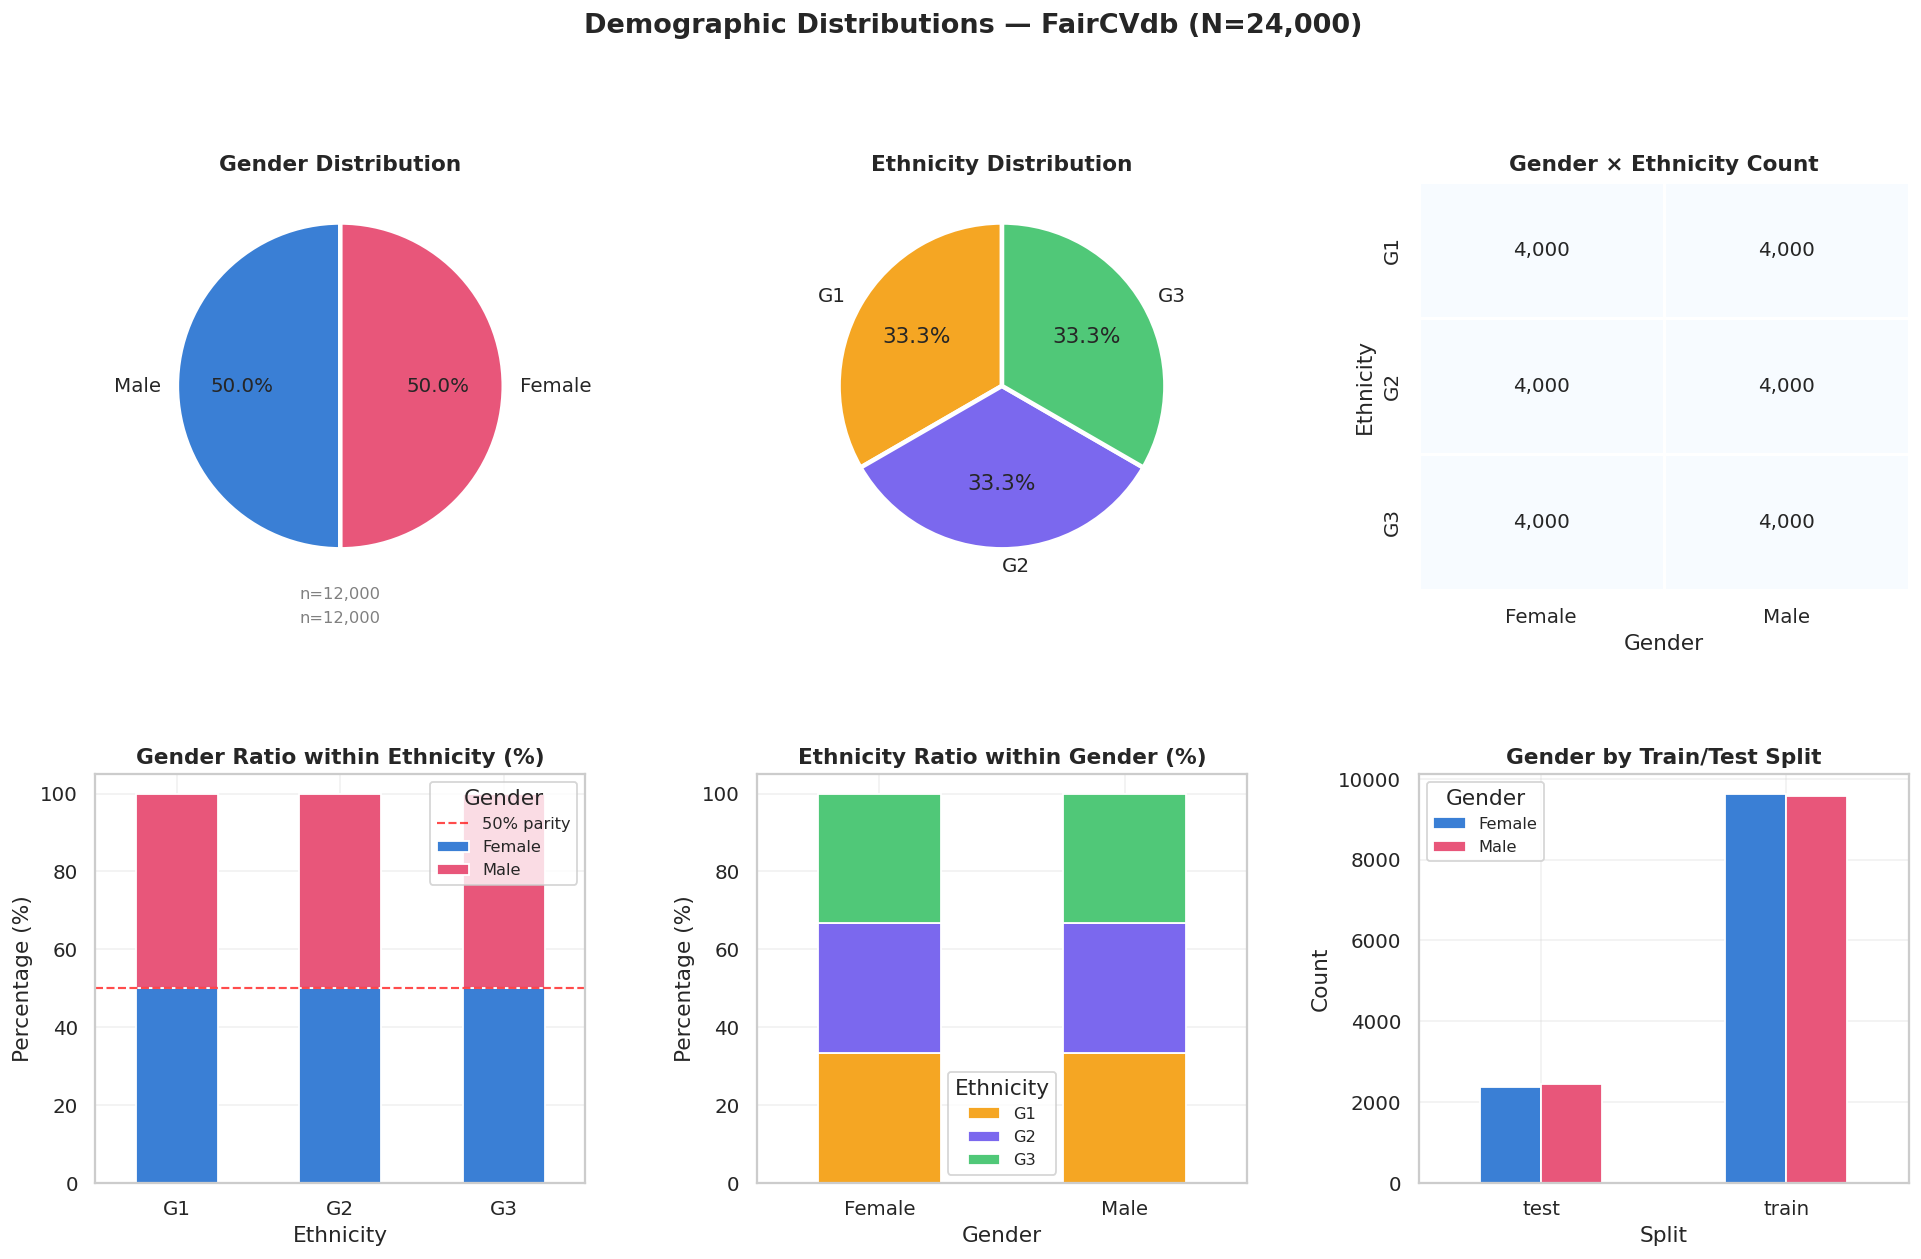

💡 Insight: Dataset is balanced — ~50/50 gender, ~33/33/33 ethnicity.
   This controlled balance is by design to enable fair metric computation.


In [6]:
# ════════════════════════════════════════════════════════════════════
# SECTION 3 — Demographic Distributions
#
# Why useful : Reveals whether the dataset is balanced across gender
#              and ethnicity groups — a prerequisite for fair evaluation.
# Insight    : Imbalanced groups → biased metrics; model may learn
#              majority-group patterns as the default.
# Fairness   : If one group is underrepresented, fairness metrics
#              (TPR, DP) may be unreliable for that group.
# ════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Demographic Distributions — FairCVdb (N=24,000)',
             fontsize=15, fontweight='bold', y=1.01)

# ── 3a. Gender pie ──────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
gc  = df['gender_label'].value_counts()
wedges, texts, autotexts = ax0.pie(
    gc.values, labels=gc.index, autopct='%1.1f%%',
    colors=[PAL_GENDER[k] for k in df['gender'].unique() if GENDER_LABELS[k] in gc.index],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2.5))
[t.set_fontsize(11) for t in autotexts]
ax0.set_title('Gender Distribution')
for i, (label, val) in enumerate(gc.items()):
    ax0.annotate(f'n={val:,}', xy=(0, 0), xytext=(0, -1.3 - i*0.15),
                 textcoords='data', ha='center', fontsize=9, color='gray')

# ── 3b. Ethnicity pie ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ec  = df['ethnicity_label'].value_counts().sort_index()
ax1.pie(ec.values, labels=ec.index, autopct='%1.1f%%',
        colors=[PAL_ETH[i] for i in range(3)],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2.5))
ax1.set_title('Ethnicity Distribution')

# ── 3c. Gender × Ethnicity heatmap ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ct  = pd.crosstab(df['ethnicity_label'], df['gender_label'])
sns.heatmap(ct, annot=True, fmt=',', cmap='Blues', ax=ax2,
            linewidths=0.8, cbar=False, annot_kws={'size': 11})
ax2.set_title('Gender × Ethnicity Count')
ax2.set_xlabel('Gender'); ax2.set_ylabel('Ethnicity')

# ── 3d. Gender × Ethnicity stacked bar ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=ax3, stacked=True,
            color=[PAL_GENDER[0], PAL_GENDER[1]], edgecolor='white',
            width=0.5, legend=True)
ax3.set_title('Gender Ratio within Ethnicity (%)')
ax3.set_xlabel('Ethnicity'); ax3.set_ylabel('Percentage (%)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.axhline(50, color='red', linestyle='--', lw=1.2, alpha=0.7, label='50% parity')
ax3.legend(title='Gender', fontsize=9)

# ── 3e. Ethnicity × Gender stacked bar ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ct2  = pd.crosstab(df['gender_label'], df['ethnicity_label'])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100
ct2_pct.plot(kind='bar', ax=ax4, stacked=True,
             color=[PAL_ETH[0], PAL_ETH[1], PAL_ETH[2]],
             edgecolor='white', width=0.5)
ax4.set_title('Ethnicity Ratio within Gender (%)')
ax4.set_xlabel('Gender'); ax4.set_ylabel('Percentage (%)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(title='Ethnicity', fontsize=9)

# ── 3f. Train vs Test demographic balance ──────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
split_demo = df.groupby(['split','gender_label']).size().unstack()
split_demo.plot(kind='bar', ax=ax5,
                color=[PAL_GENDER[0], PAL_GENDER[1]],
                edgecolor='white', width=0.5)
ax5.set_title('Gender by Train/Test Split')
ax5.set_xlabel('Split'); ax5.set_ylabel('Count')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0)
ax5.legend(title='Gender', fontsize=9)

plt.savefig('sec3_demographics.png', bbox_inches='tight', dpi=150)
plt.show()
print('💡 Insight: Dataset is balanced — ~50/50 gender, ~33/33/33 ethnicity.')
print('   This controlled balance is by design to enable fair metric computation.')

---
## 4. Occupation & Sector Analysis

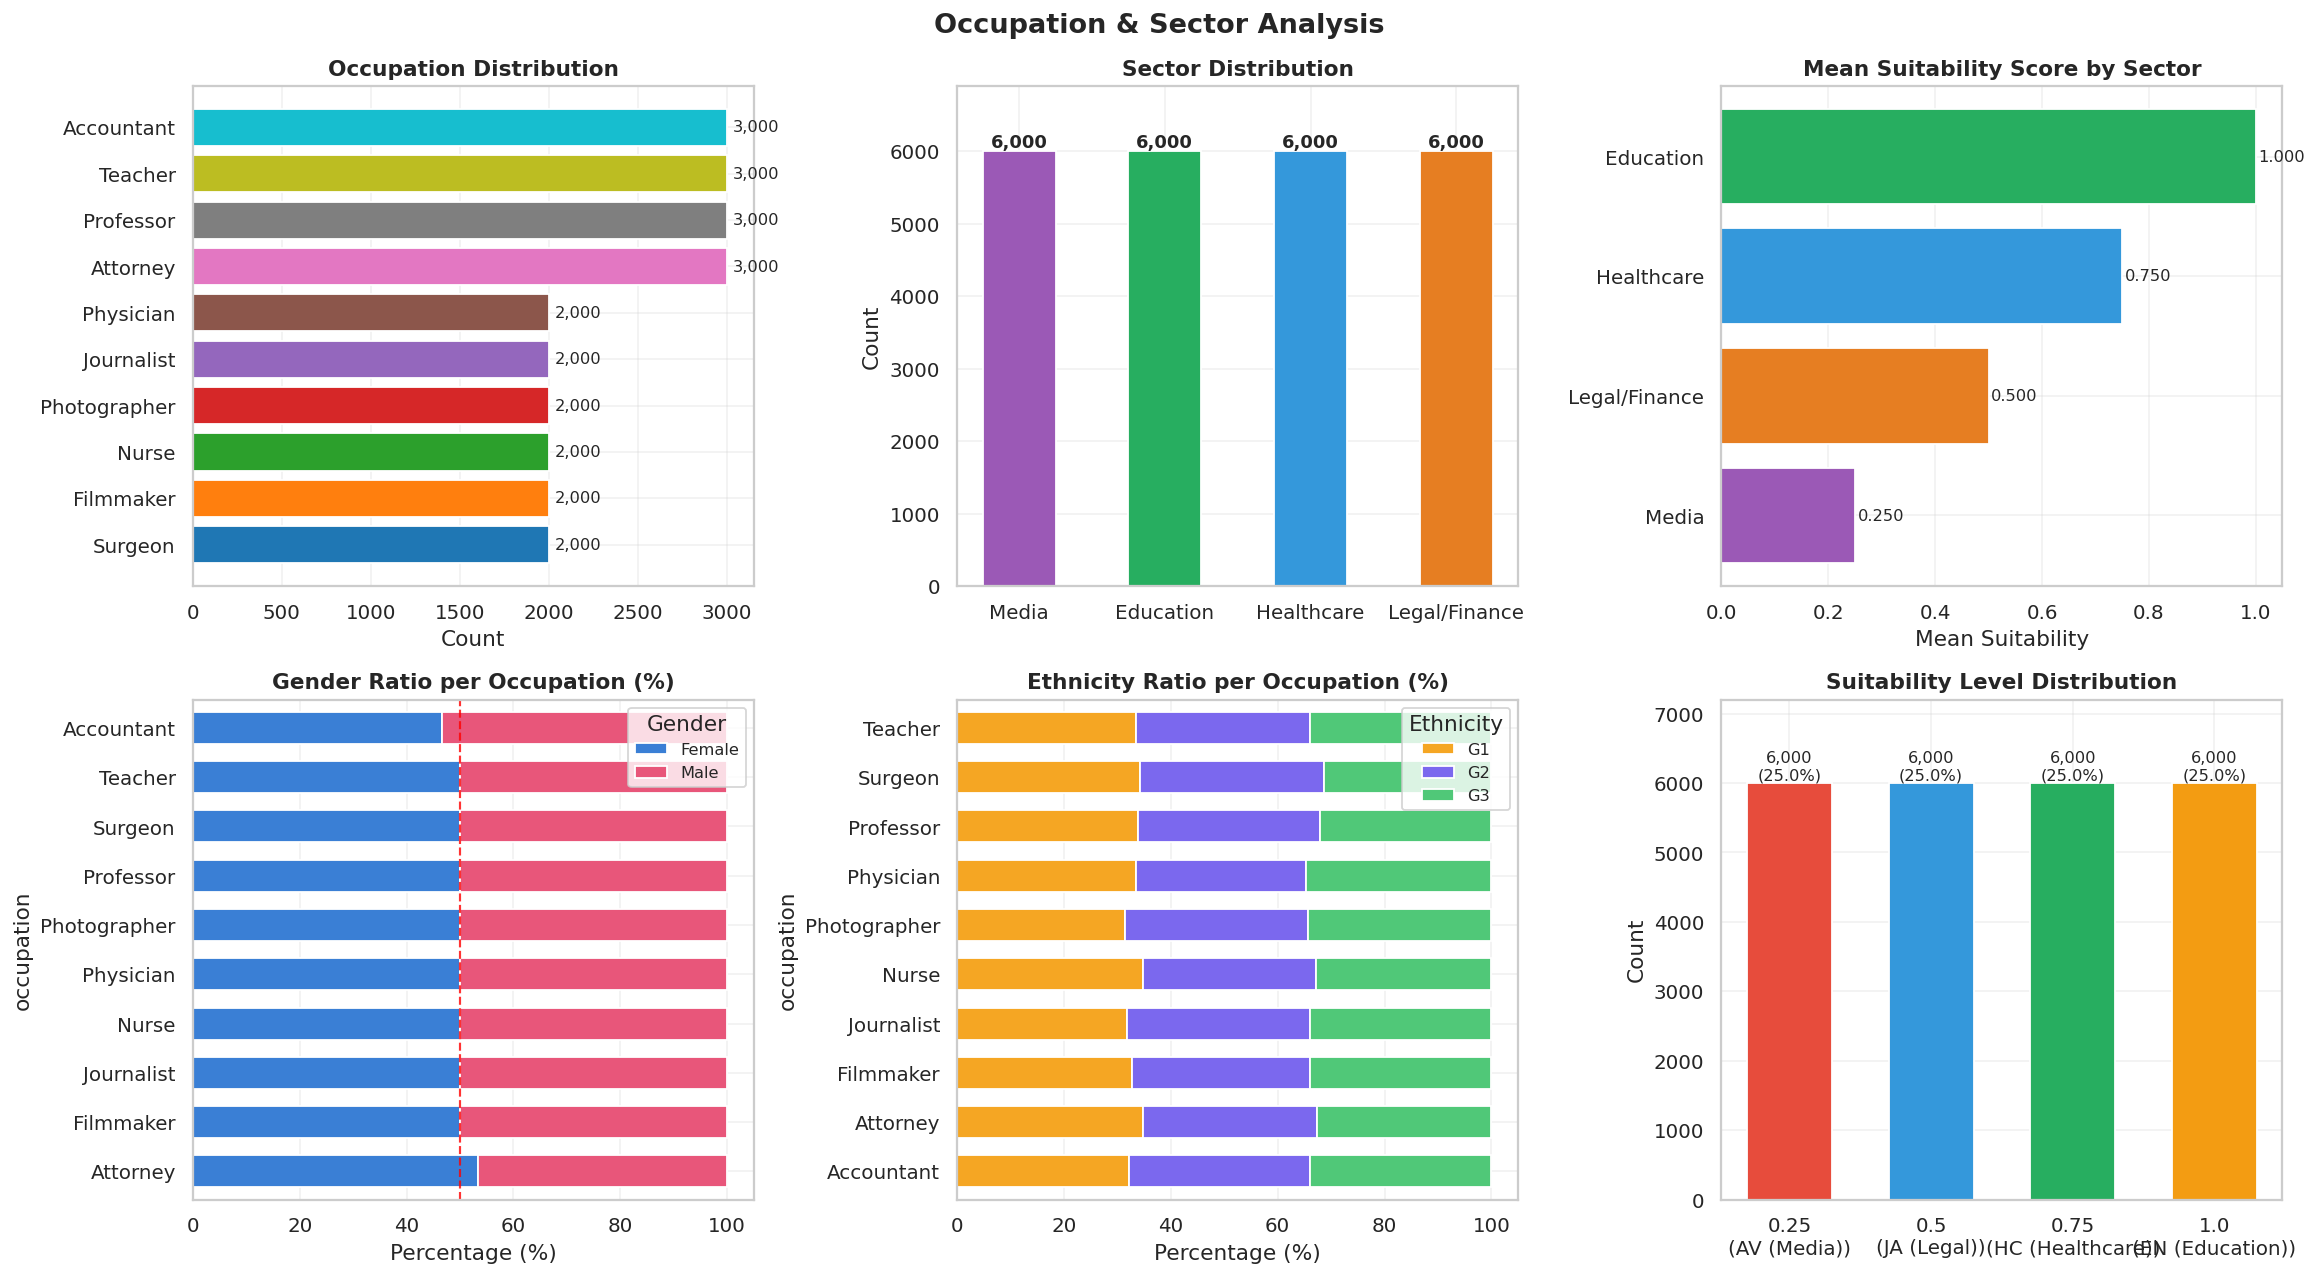

   Insight: Occupation distribution is intentionally balanced.
   Gender/ethnicity split per occupation is ~equal — controlled by design.
   Suitability varies by sector and directly affects the blind_label score.


In [7]:
# ════════════════════════════════════════════════════════════════════
# SECTION 4 — Occupation & Sector Analysis
#
# Why useful : Occupations have different suitability scores, creating
#              natural score differences that interact with demographics.
# Insight    : If certain occupations are overrepresented by one gender,
#              model may learn spurious occupation-gender correlations.
# Fairness   : Occupation × demographic imbalance is a proxy bias risk.
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Occupation & Sector Analysis', fontsize=15, fontweight='bold')

# ── 4a. Occupation count ────────────────────────────────────────────
ax = axes[0][0]
oc = df['occupation'].value_counts().sort_values(ascending=True)
bars = ax.barh(oc.index, oc.values,
               color=PAL_OCC[:len(oc)], edgecolor='white')
for bar, val in zip(bars, oc.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Occupation Distribution')
ax.set_xlabel('Count')

# ── 4b. Sector count ────────────────────────────────────────────────
ax = axes[0][1]
sc = df['sector'].value_counts()
bars = ax.bar(sc.index, sc.values,
              color=[PAL_SECTOR[s] for s in sc.index],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, sc.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50, f'{val:,}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Sector Distribution')
ax.set_ylabel('Count')
ax.set_ylim(0, sc.max() * 1.15)

# ── 4c. Suitability by sector ───────────────────────────────────────
ax = axes[0][2]
suit_sec = df.groupby('sector')['suitability'].mean().sort_values()
bars = ax.barh(suit_sec.index, suit_sec.values,
               color=[PAL_SECTOR[s] for s in suit_sec.index])
for bar, val in zip(bars, suit_sec.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Mean Suitability Score by Sector')
ax.set_xlabel('Mean Suitability')

# ── 4d. Gender split per occupation ─────────────────────────────────
ax = axes[1][0]
occ_gen = pd.crosstab(df['occupation'], df['gender_label'])
occ_gen_pct = occ_gen.div(occ_gen.sum(axis=1), axis=0) * 100
occ_gen_pct = occ_gen_pct.sort_values('Male')
occ_gen_pct.plot(kind='barh', stacked=True, ax=ax,
                 color=[PAL_GENDER[0], PAL_GENDER[1]],
                 edgecolor='white', width=0.65)
ax.axvline(50, color='red', linestyle='--', lw=1.2, alpha=0.8)
ax.set_title('Gender Ratio per Occupation (%)')
ax.set_xlabel('Percentage (%)')
ax.legend(title='Gender', fontsize=9)

# ── 4e. Ethnicity split per occupation ──────────────────────────────
ax = axes[1][1]
occ_eth = pd.crosstab(df['occupation'], df['ethnicity_label'])
occ_eth_pct = occ_eth.div(occ_eth.sum(axis=1), axis=0) * 100
occ_eth_pct.plot(kind='barh', stacked=True, ax=ax,
                 color=[PAL_ETH[i] for i in range(3)],
                 edgecolor='white', width=0.65)
ax.set_title('Ethnicity Ratio per Occupation (%)')
ax.set_xlabel('Percentage (%)')
ax.legend(title='Ethnicity', fontsize=9)

# ── 4f. Suitability distribution (histogram) ────────────────────────
ax = axes[1][2]
suit_vc = df['suitability'].value_counts().sort_index()
bars = ax.bar([f'{v}\n({SUIT_MAP[v]})' for v in suit_vc.index],
              suit_vc.values,
              color=['#E74C3C','#3498DB','#27AE60','#F39C12'],
              edgecolor='white', width=0.6)
for bar, val in zip(bars, suit_vc.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50, f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=9)
ax.set_title('Suitability Level Distribution')
ax.set_ylabel('Count')
ax.set_ylim(0, suit_vc.max() * 1.2)

plt.tight_layout()
plt.savefig('sec4_occupation.png', bbox_inches='tight', dpi=150)
plt.show()
print('   Insight: Occupation distribution is intentionally balanced.')
print('   Gender/ethnicity split per occupation is ~equal — controlled by design.')
print('   Suitability varies by sector and directly affects the blind_label score.')

---
## 5. Competency Feature Distributions

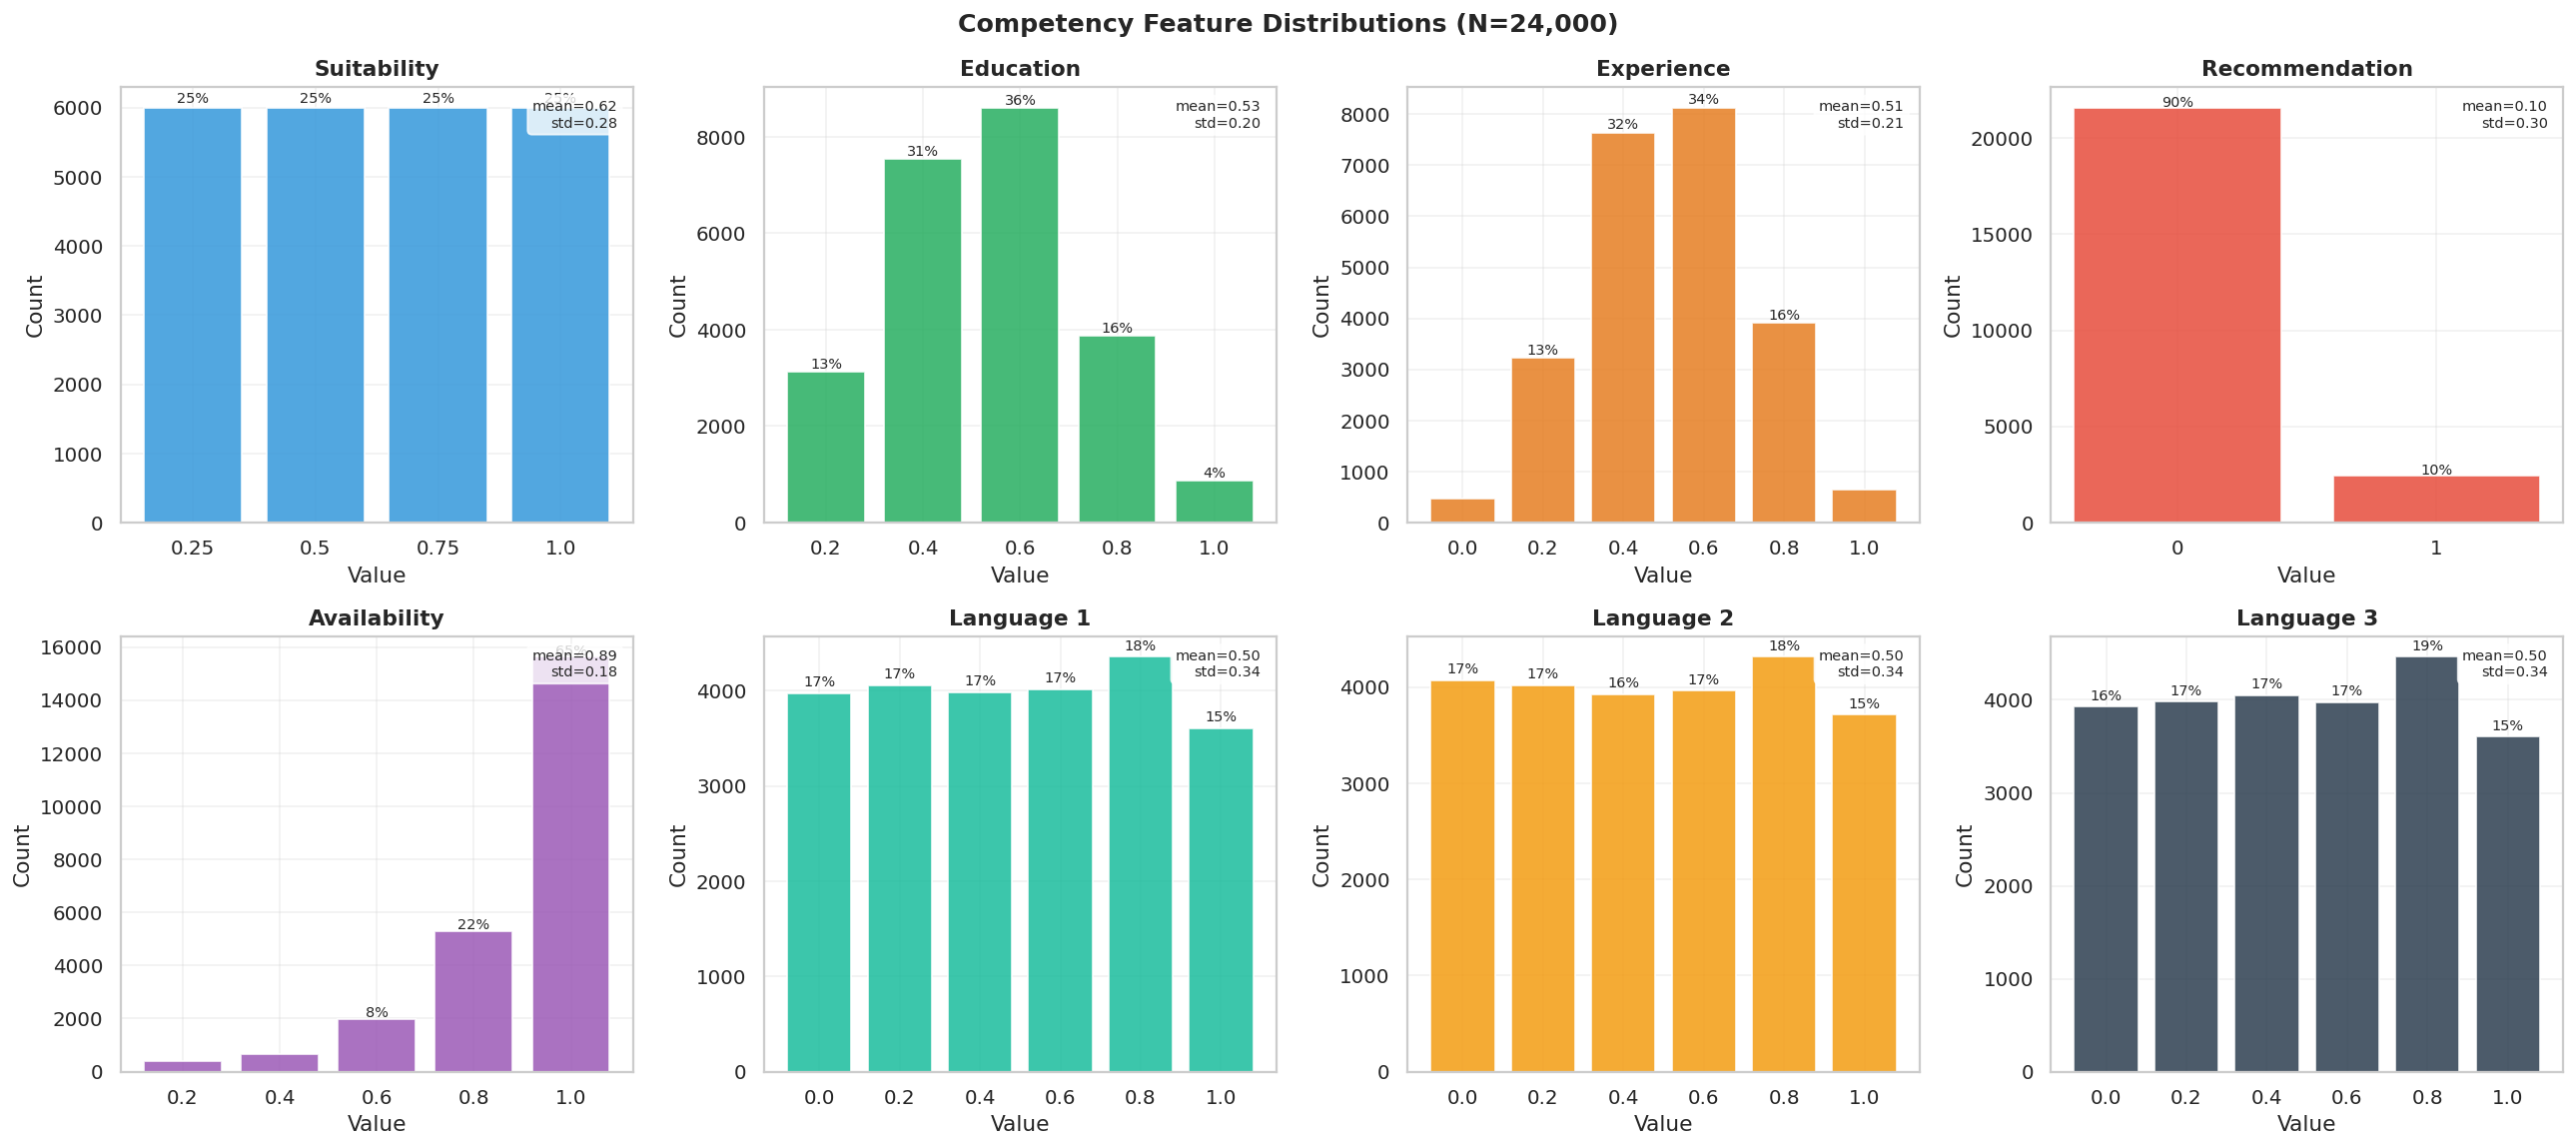

In [8]:
# ════════════════════════════════════════════════════════════════════
# SECTION 5 — Competency Feature Distributions
#
# Why useful : These are the PRIMARY inputs to recruitment models.
#              Understanding their distributions reveals range, skew,
#              and whether they differ across demographic groups.
# Insight    : If competency distributions are equal across groups,
#              any score gap is evidence of bias in labeling/model.
# Fairness   : Score differences not explained by competency = bias.
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Competency Feature Distributions (N=24,000)', fontsize=14, fontweight='bold')

feat_colors = ['#3498DB','#27AE60','#E67E22','#E74C3C',
               '#9B59B6','#1ABC9C','#F39C12','#2C3E50']

for ax, feat, label, color in zip(axes.flat, COMPETENCY, COMP_LABELS, feat_colors):
    vc    = df[feat].value_counts().sort_index()
    total = vc.sum()
    bars  = ax.bar([str(round(v, 2)) for v in vc.index], vc.values,
                   color=color, alpha=0.85, edgecolor='white')
    # Percentage labels on bars
    for bar, val in zip(bars, vc.values):
        pct = val / total * 100
        if pct > 3:  # only label if bar is wide enough
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + total*0.003,
                    f'{pct:.0f}%', ha='center', fontsize=8)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    # Stat annotation
    ax.text(0.97, 0.97,
            f'mean={df[feat].mean():.2f}\nstd={df[feat].std():.2f}',
            transform=ax.transAxes, fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('sec5a_competency_dist.png', bbox_inches='tight', dpi=150)
plt.show()

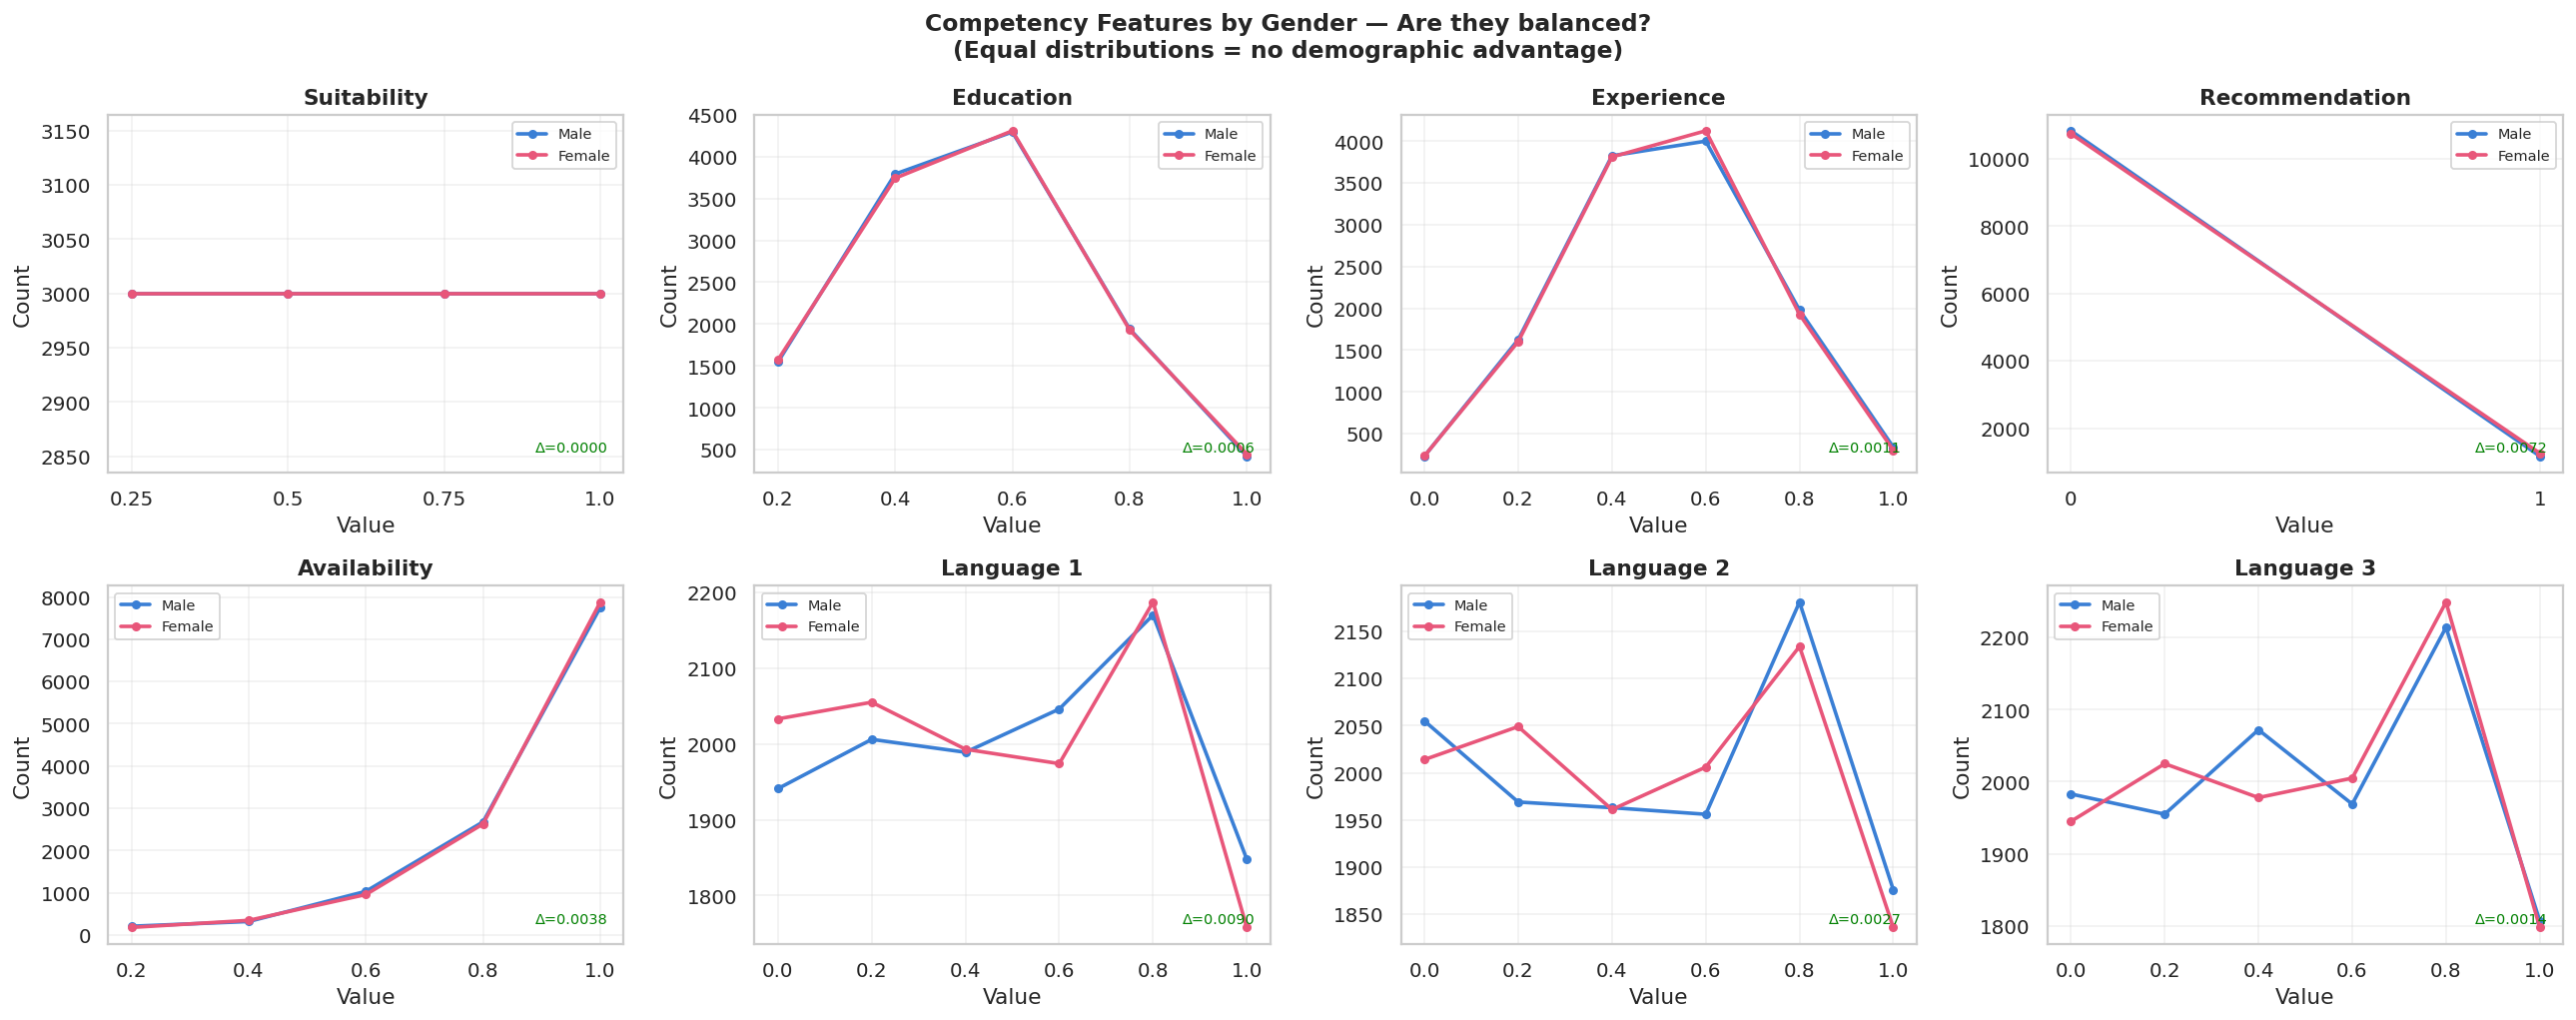

   Insight: Competency features are equalized across gender by design.
   Δ ≈ 0 for all features → any score gap is due to labeling bias, not merit.


In [9]:
# ── 5b. Competency mean by Gender (should be ~equal if fair) ────────
# Fairness check: if Gender predicts competency → spurious correlation

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Competency Features by Gender — Are they balanced?\n'
             '(Equal distributions = no demographic advantage)',
             fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flat, COMPETENCY, COMP_LABELS):
    for gval, glabel in GENDER_LABELS.items():
        vals = df[df['gender'] == gval][feat]
        vc   = vals.value_counts().sort_index()
        ax.plot([str(round(v, 2)) for v in vc.index], vc.values,
                marker='o', label=glabel, color=PAL_GENDER[gval],
                linewidth=2, markersize=4)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    # Annotate mean difference
    m_mean = df[df['gender']==0][feat].mean()
    f_mean = df[df['gender']==1][feat].mean()
    ax.text(0.97, 0.05, f'Δ={abs(m_mean-f_mean):.4f}',
            transform=ax.transAxes, fontsize=8, va='bottom', ha='right',
            color='green' if abs(m_mean-f_mean) < 0.01 else 'red')

plt.tight_layout()
plt.savefig('sec5b_competency_by_gender.png', bbox_inches='tight', dpi=150)
plt.show()
print('   Insight: Competency features are equalized across gender by design.')
print('   Δ ≈ 0 for all features → any score gap is due to labeling bias, not merit.')

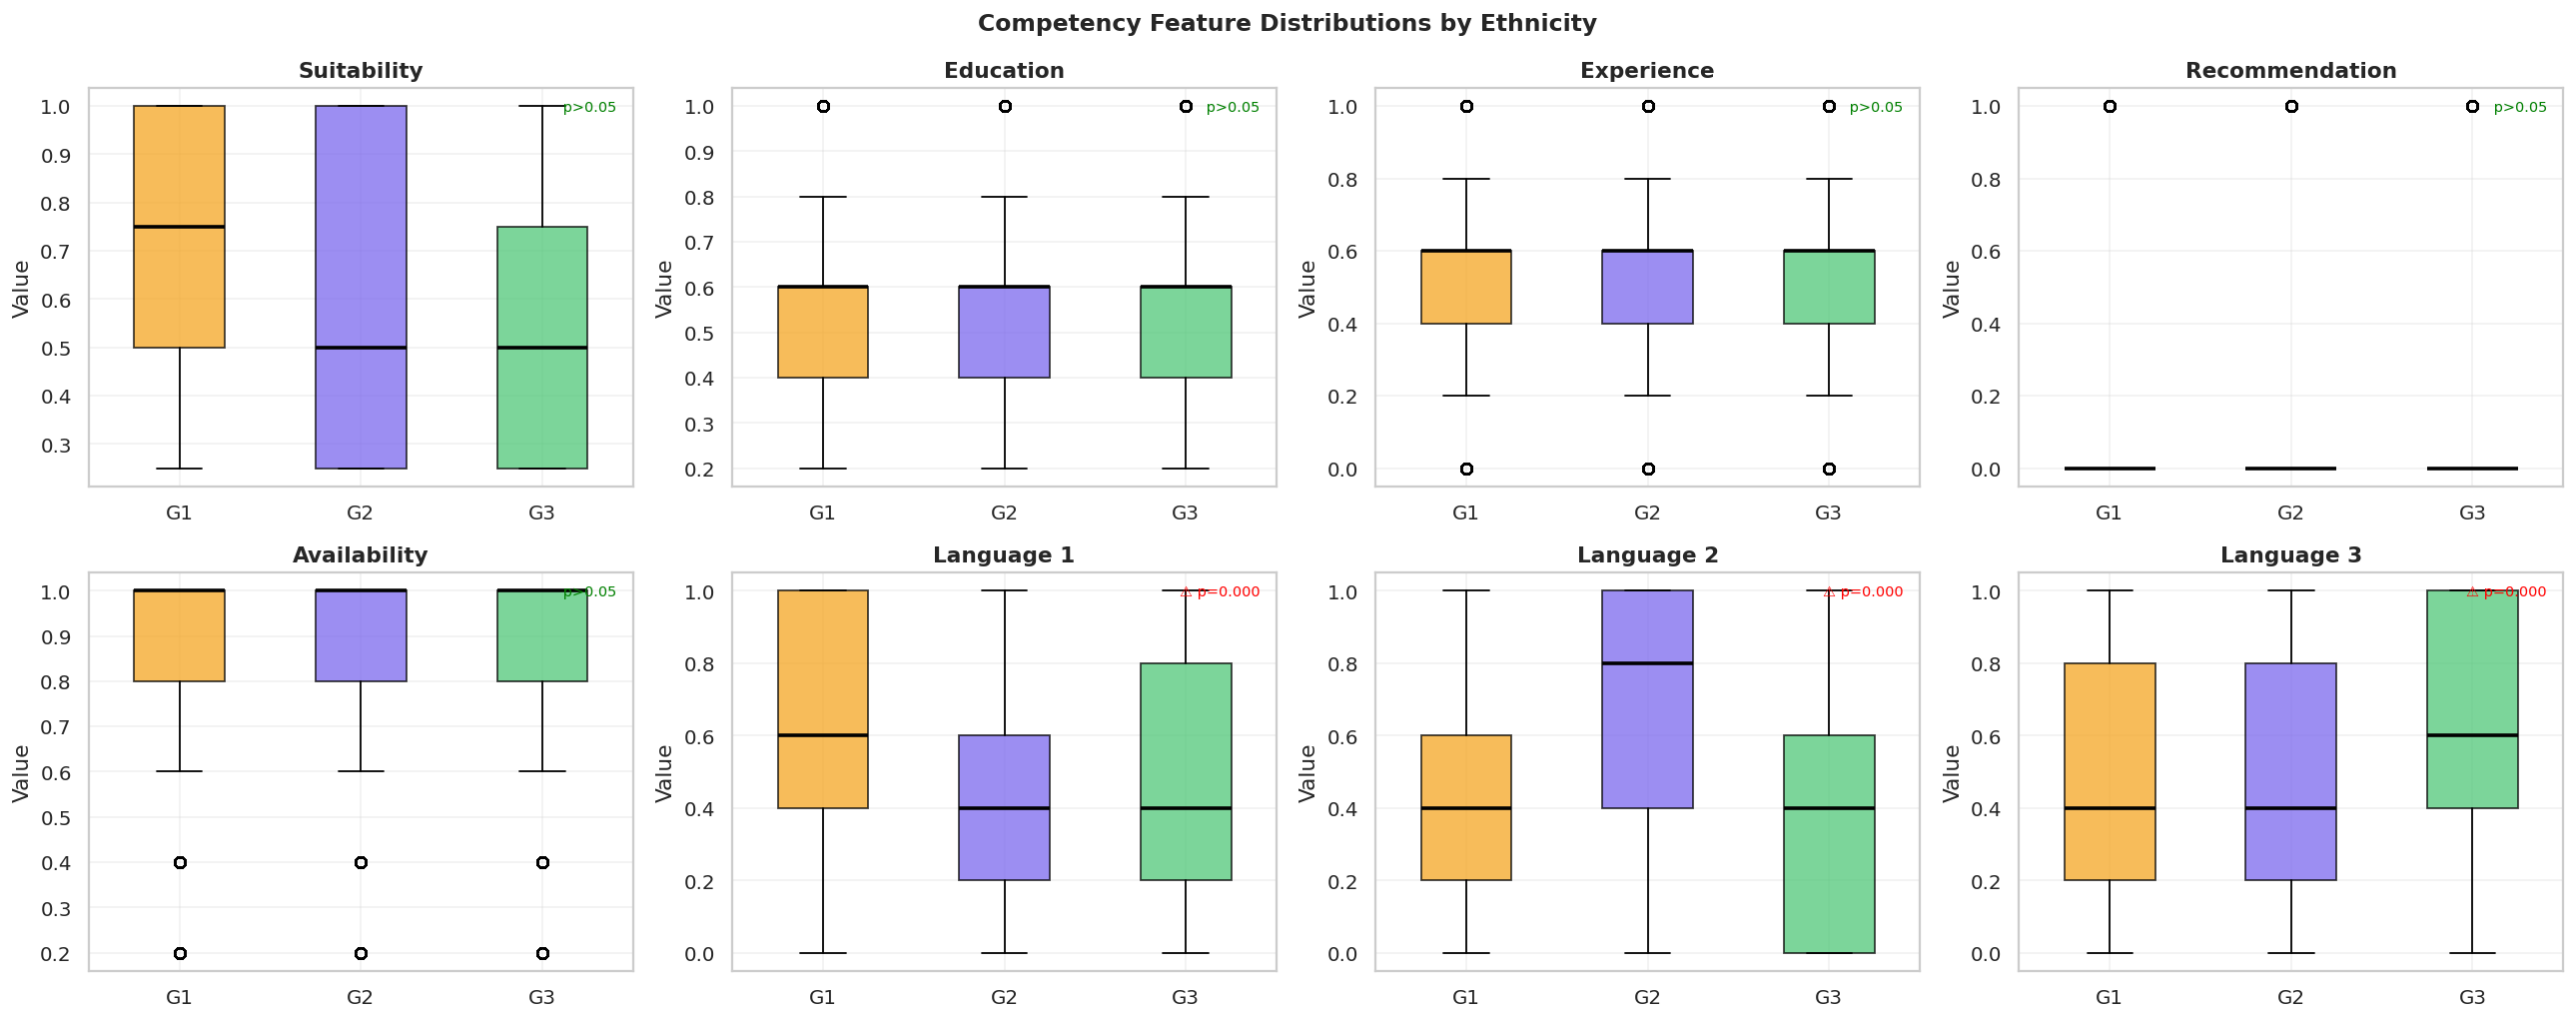

   If ANOVA p > 0.05: no significant difference across ethnicity groups.
   This confirms competency is ethnicity-agnostic — bias must come from labels.


In [10]:
# ── 5c. Boxplots: Competency by Ethnicity ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Competency Feature Distributions by Ethnicity',
             fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flat, COMPETENCY, COMP_LABELS):
    data_by_eth = [df[df['ethnicity']==g][feat].values for g in [0,1,2]]
    bp = ax.boxplot(data_by_eth, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, gid in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(PAL_ETH[gid]); patch.set_alpha(0.75)
    ax.set_xticklabels(['G1','G2','G3'])
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Value')
    # ANOVA p-value to test statistical difference
    f_stat, p_val = stats.f_oneway(*data_by_eth)
    sig = ' p>0.05' if p_val > 0.05 else f'⚠️ p={p_val:.3f}'
    ax.text(0.97, 0.97, sig, transform=ax.transAxes,
            fontsize=8, va='top', ha='right',
            color='green' if p_val > 0.05 else 'red')

plt.tight_layout()
plt.savefig('sec5c_competency_by_ethnicity.png', bbox_inches='tight', dpi=150)
plt.show()
print('   If ANOVA p > 0.05: no significant difference across ethnicity groups.')
print('   This confirms competency is ethnicity-agnostic — bias must come from labels.')

---
## 6. Label Distributions

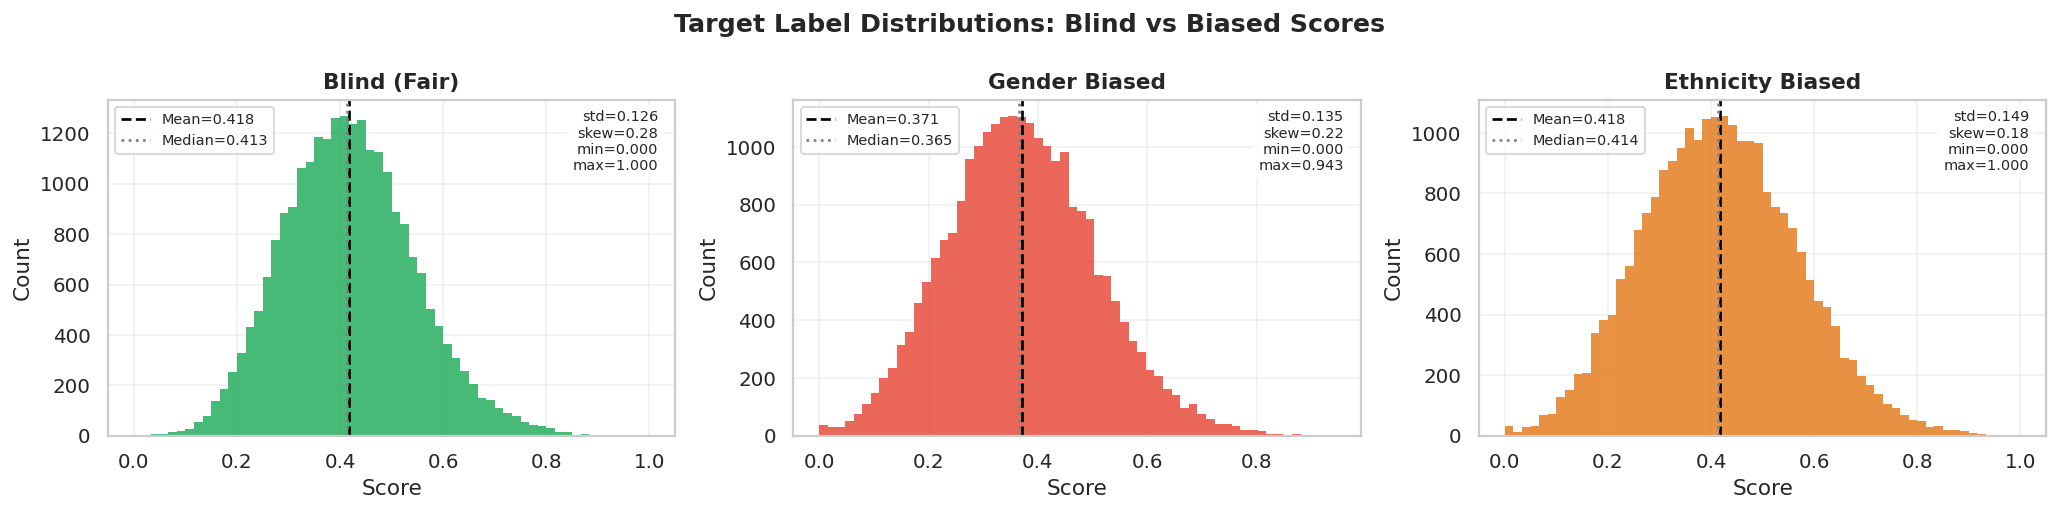

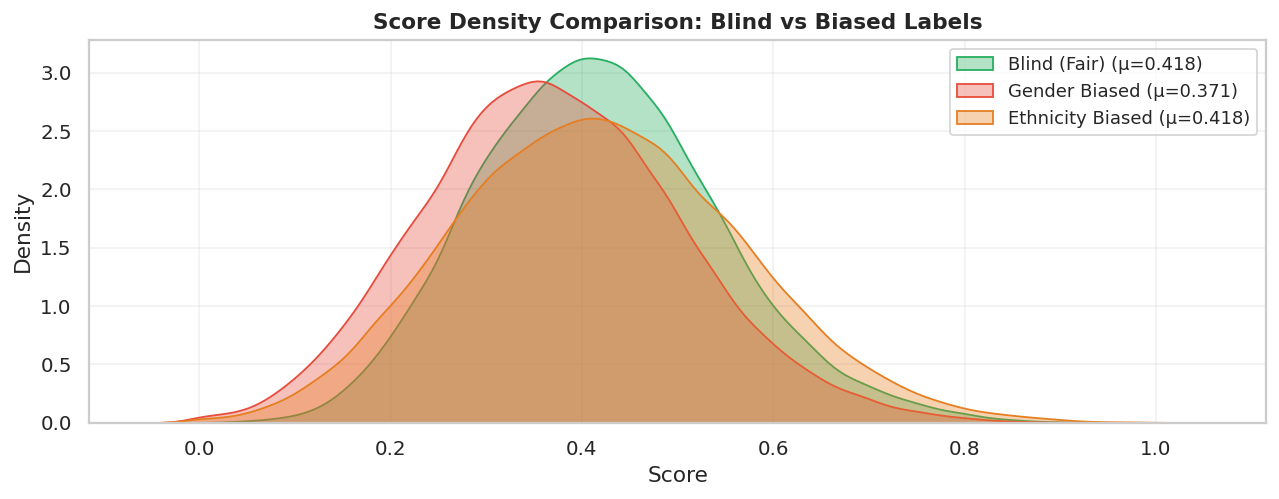

   Mean shift: Blind=0.4179
               Gender Biased=0.3708 (Δ=-0.0471)
               Eth Biased=0.4178 (Δ=-0.0001)


In [12]:
# ════════════════════════════════════════════════════════════════════
# SECTION 6 — Label Distributions
#
# Why useful : The three labels represent 3 different scoring regimes:
#              fair (blind), gender-biased, ethnicity-biased.
#              Comparing them reveals the magnitude of injected bias.
# Insight    : Score shift between blind and biased labels quantifies
#              how much penalty was applied to each group.
# Fairness   : Larger KL divergence = larger bias.
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Target Label Distributions: Blind vs Biased Scores',
             fontsize=14, fontweight='bold')

for ax, col, name, color in zip(axes, LABEL_COLS, LABEL_NAMES,
                                 [PAL_LABEL['Blind'], PAL_LABEL['Gender Bias'], PAL_LABEL['Eth Bias']]):
    vals = df[col]
    ax.hist(vals, bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(vals.mean(),   color='black', linestyle='--', lw=1.5,
               label=f'Mean={vals.mean():.3f}')
    ax.axvline(vals.median(), color='gray',  linestyle=':',  lw=1.5,
               label=f'Median={vals.median():.3f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    # Stats box
    skew = stats.skew(vals)
    ax.text(0.97, 0.97,
            f'std={vals.std():.3f}\nskew={skew:.2f}\nmin={vals.min():.3f}\nmax={vals.max():.3f}',
            transform=ax.transAxes, fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('sec6a_label_dist.png', bbox_inches='tight', dpi=150)
plt.show()

# Overlap plot
fig, ax = plt.subplots(figsize=(10, 4))
for col, name, color in zip(LABEL_COLS, LABEL_NAMES,
                             [PAL_LABEL['Blind'], PAL_LABEL['Gender Bias'], PAL_LABEL['Eth Bias']]):
    sns.kdeplot(df[col], ax=ax, fill=True, alpha=0.35, color=color,
                label=f'{name} (μ={df[col].mean():.3f})')
ax.set_title('Score Density Comparison: Blind vs Biased Labels', fontweight='bold')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('sec6b_label_overlap.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'   Mean shift: Blind={df["blind_label"].mean():.4f}')
print(f'               Gender Biased={df["biased_label_gender"].mean():.4f}',
      f'(Δ={df["biased_label_gender"].mean()-df["blind_label"].mean():.4f})')
print(f'               Eth Biased={df["biased_label_ethnicity"].mean():.4f}',
      f'(Δ={df["biased_label_ethnicity"].mean()-df["blind_label"].mean():.4f})')

---
## 7. Fairness & Bias Analysis

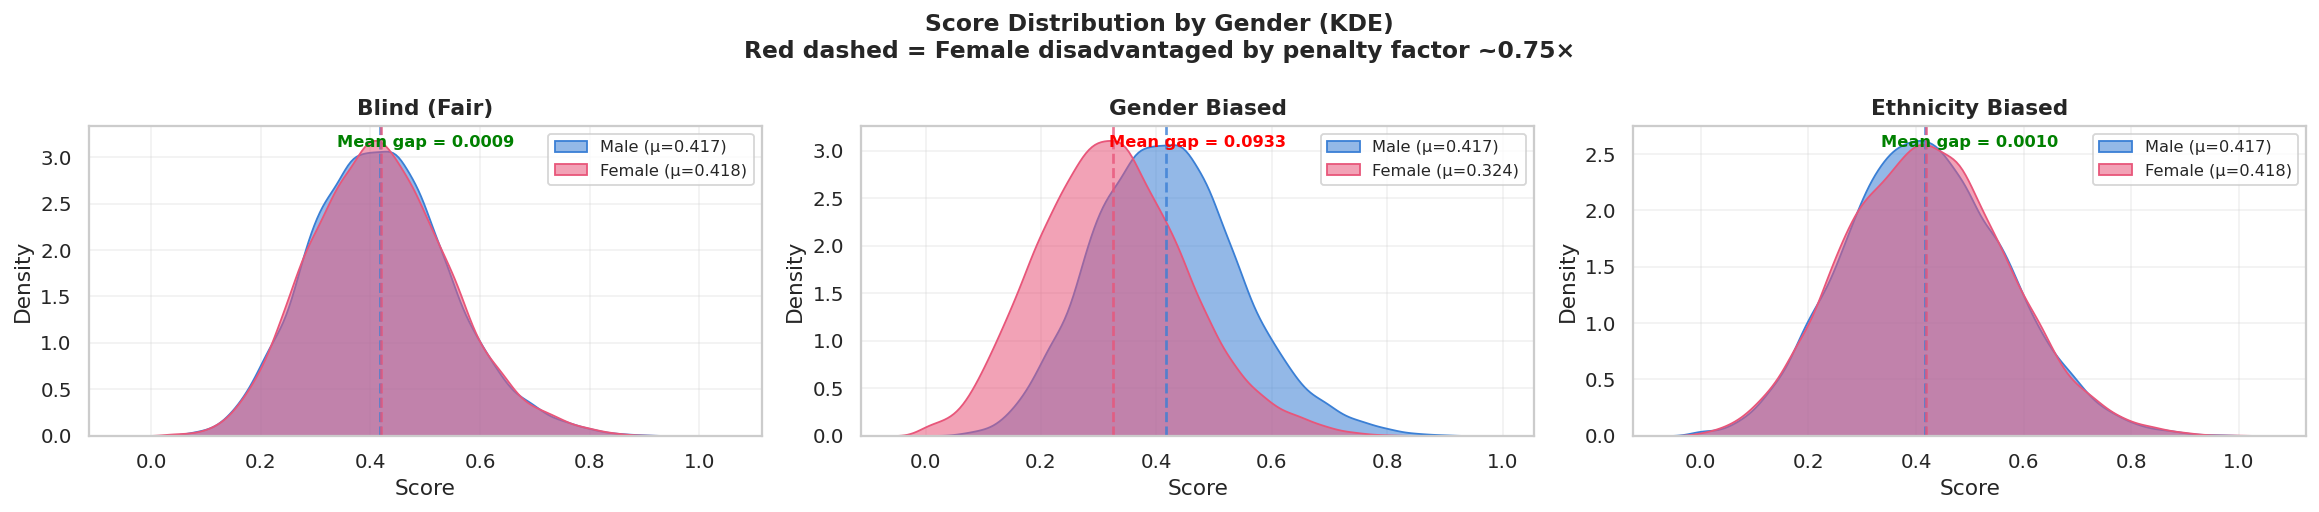

In [11]:
# ════════════════════════════════════════════════════════════════════
# SECTION 7 — Fairness & Bias Analysis
#
# Why useful : Core research objective — quantify how bias in labels
#              translates to discriminatory score distributions.
# Insight    : KDE overlap, boxplots, and mean gaps expose exactly
#              which groups are disadvantaged and by how much.
# Fairness   : Demographic Parity requires equal mean scores.
#              Equal Opportunity requires equal TPR across groups.
# ════════════════════════════════════════════════════════════════════

# ── 7a. Score KDE by Gender — all 3 labels ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Score Distribution by Gender (KDE)\n'
             'Red dashed = Female disadvantaged by penalty factor ~0.75×',
             fontsize=13, fontweight='bold')

for ax, col, name in zip(axes, LABEL_COLS, LABEL_NAMES):
    for gval, glabel in GENDER_LABELS.items():
        vals = df[df['gender'] == gval][col]
        sns.kdeplot(vals, ax=ax, fill=True, alpha=0.55,
                    color=PAL_GENDER[gval],
                    label=f'{glabel} (μ={vals.mean():.3f})')
        ax.axvline(vals.mean(), color=PAL_GENDER[gval],
                   linestyle='--', lw=1.5, alpha=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    # Gap annotation
    gap = abs(df[df['gender']==0][col].mean() - df[df['gender']==1][col].mean())
    ax.text(0.5, 0.97, f'Mean gap = {gap:.4f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=9,
            color='red' if gap > 0.005 else 'green', fontweight='bold')

plt.tight_layout()
plt.savefig('sec7a_kde_gender.png', bbox_inches='tight', dpi=150)
plt.show()

---## FAIRE Counterfactual Minimal Pairs

In [12]:
# === FAIRE Counterfactual Minimal Pairs (Exploratory) ===

import pandas as pd

# Minimal gender pairs
gender_pairs = [
    {'original': 'John Smith - Software Engineer', 'variant': 'Jane Smith - Software Engineer'},
    {'original': 'Michael Johnson - Project Manager', 'variant': 'Michelle Johnson - Project Manager'},
    {'original': 'David Lee - Data Analyst', 'variant': 'Diana Lee - Data Analyst'},
]

# Minimal ethnicity pairs
ethnicity_pairs = [
    {'original': 'John Smith - Software Engineer', 'variant': 'Rajesh Patel - Software Engineer'},
    {'original': 'Michael Johnson - Project Manager', 'variant': 'Miguel Gonzalez - Project Manager'},
    {'original': 'David Lee - Data Analyst', 'variant': 'Wei Chen - Data Analyst'},
]

print("="*80)
print("FAIRE Counterfactual Minimal Pairs (Exploratory)")
print("="*80 + "\n")

print("Gender Pairs (same resume, different gender cues):")
print("-" * 80)
for i, pair in enumerate(gender_pairs, 1):
    print(f"{i}. Original: {pair['original']}")
    print(f"   Variant:  {pair['variant']}\n")

print("\nEthnicity Pairs (same resume, different ethnicity cues):")
print("-" * 80)
for i, pair in enumerate(ethnicity_pairs, 1):
    print(f"{i}. Original: {pair['original']}")
    print(f"   Variant:  {pair['variant']}\n")

print("""
📌 FAIRE Concept (from Wen et al. 2025):
  • Create minimal pairs: identical resume except for ONE demographic signal (name)
  • If predictions shift only due to name change → bias detected
  • Higher shift = stronger bias in resume evaluation
""")

FAIRE Counterfactual Minimal Pairs (Exploratory)

Gender Pairs (same resume, different gender cues):
--------------------------------------------------------------------------------
1. Original: John Smith - Software Engineer
   Variant:  Jane Smith - Software Engineer

2. Original: Michael Johnson - Project Manager
   Variant:  Michelle Johnson - Project Manager

3. Original: David Lee - Data Analyst
   Variant:  Diana Lee - Data Analyst


Ethnicity Pairs (same resume, different ethnicity cues):
--------------------------------------------------------------------------------
1. Original: John Smith - Software Engineer
   Variant:  Rajesh Patel - Software Engineer

2. Original: Michael Johnson - Project Manager
   Variant:  Miguel Gonzalez - Project Manager

3. Original: David Lee - Data Analyst
   Variant:  Wei Chen - Data Analyst


📌 FAIRE Concept (from Wen et al. 2025):
  • Create minimal pairs: identical resume except for ONE demographic signal (name)
  • If predictions shift only 

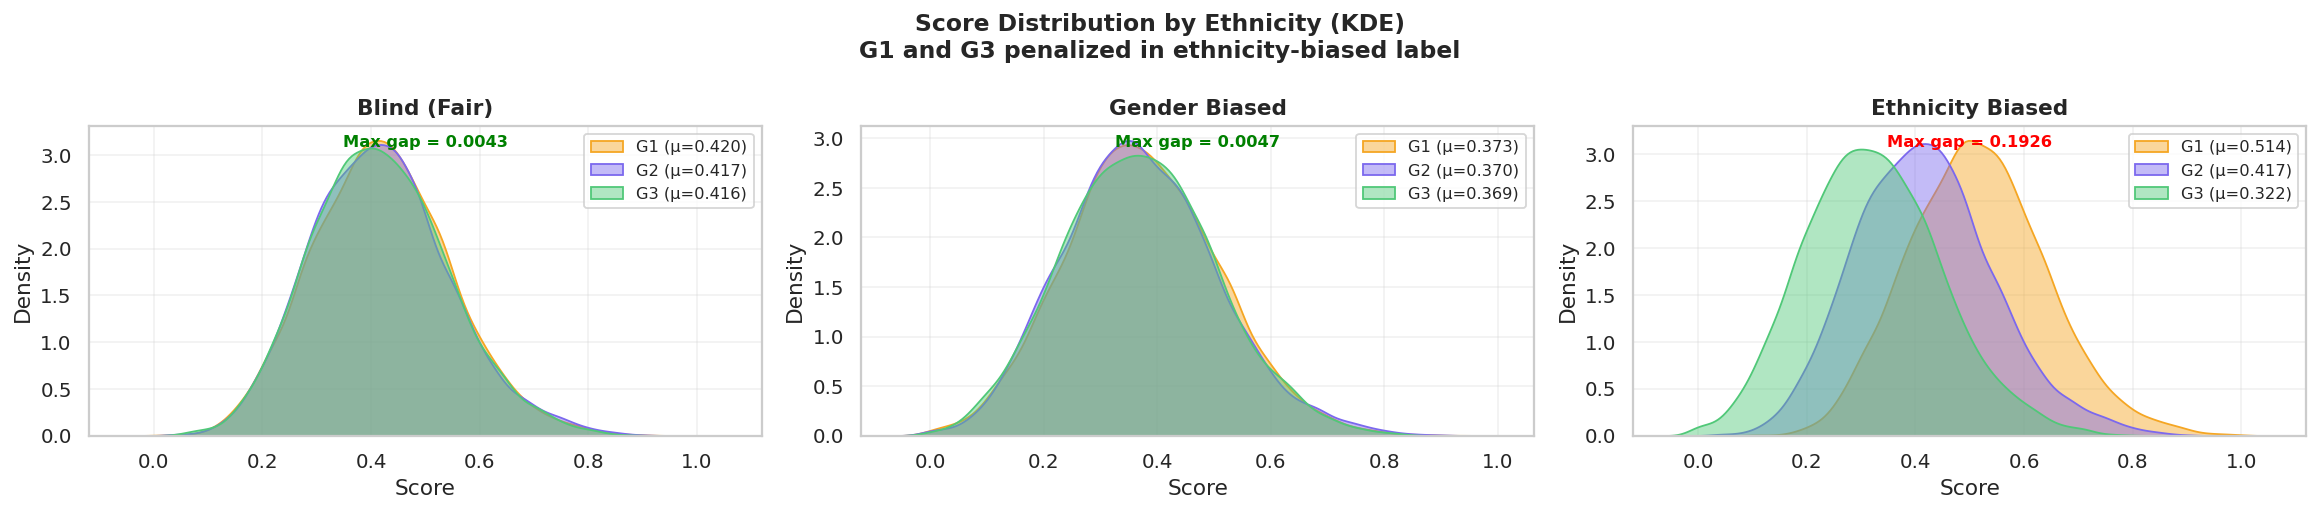

In [13]:
# ── 7b. Score KDE by Ethnicity — all 3 labels ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Score Distribution by Ethnicity (KDE)\n'
             'G1 and G3 penalized in ethnicity-biased label',
             fontsize=13, fontweight='bold')

for ax, col, name in zip(axes, LABEL_COLS, LABEL_NAMES):
    for gid, glabel in ETH_LABELS.items():
        vals = df[df['ethnicity'] == gid][col]
        sns.kdeplot(vals, ax=ax, fill=True, alpha=0.45,
                    color=PAL_ETH[gid],
                    label=f'{glabel} (μ={vals.mean():.3f})')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    means = [df[df['ethnicity']==g][col].mean() for g in [0,1,2]]
    gap   = max(means) - min(means)
    ax.text(0.5, 0.97, f'Max gap = {gap:.4f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=9,
            color='red' if gap > 0.005 else 'green', fontweight='bold')

plt.tight_layout()
plt.savefig('sec7b_kde_ethnicity.png', bbox_inches='tight', dpi=150)
plt.show()

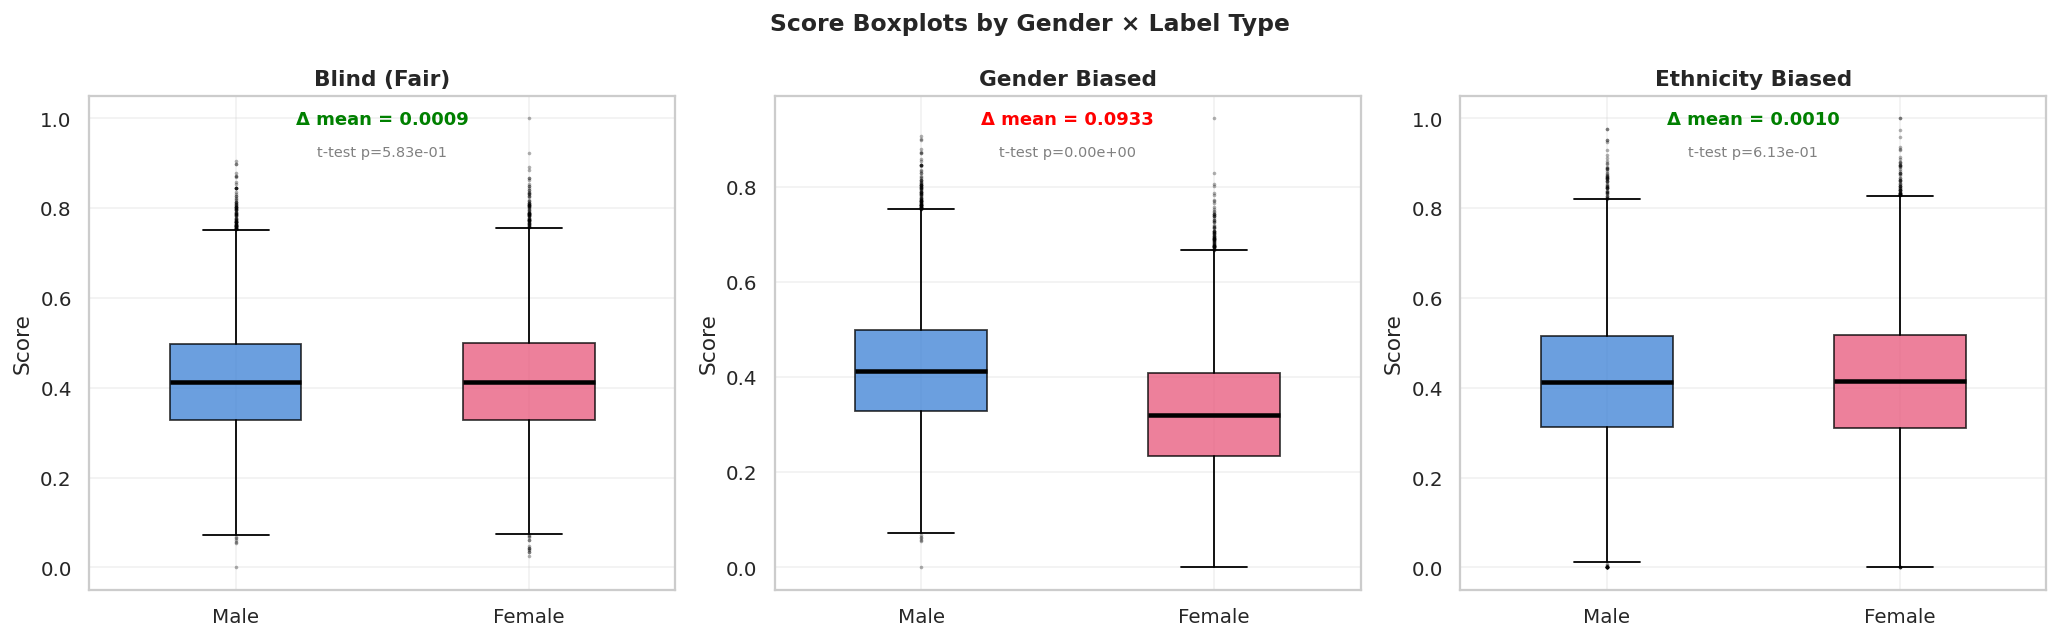

In [16]:
# ── 7c. Boxplots — Score by Gender × Label ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Score Boxplots by Gender × Label Type', fontsize=13, fontweight='bold')

for ax, col, name in zip(axes, LABEL_COLS, LABEL_NAMES):
    data = [df[df['gender']==g][col].values for g in [0,1]]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.45,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, gid in zip(bp['boxes'], [0,1]):
        patch.set_facecolor(PAL_GENDER[gid]); patch.set_alpha(0.75)
    ax.set_xticklabels(['Male','Female'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Score')
    gap = abs(np.mean(data[0]) - np.mean(data[1]))
    ax.text(0.5, 0.97, f'Δ mean = {gap:.4f}',
            transform=ax.transAxes, ha='center', va='top',
            color='red' if gap > 0.005 else 'green',
            fontweight='bold', fontsize=10)
    # t-test
    t, p = stats.ttest_ind(data[0], data[1])
    ax.text(0.5, 0.90, f't-test p={p:.2e}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('sec7c_boxplot_gender.png', bbox_inches='tight', dpi=150)
plt.show()

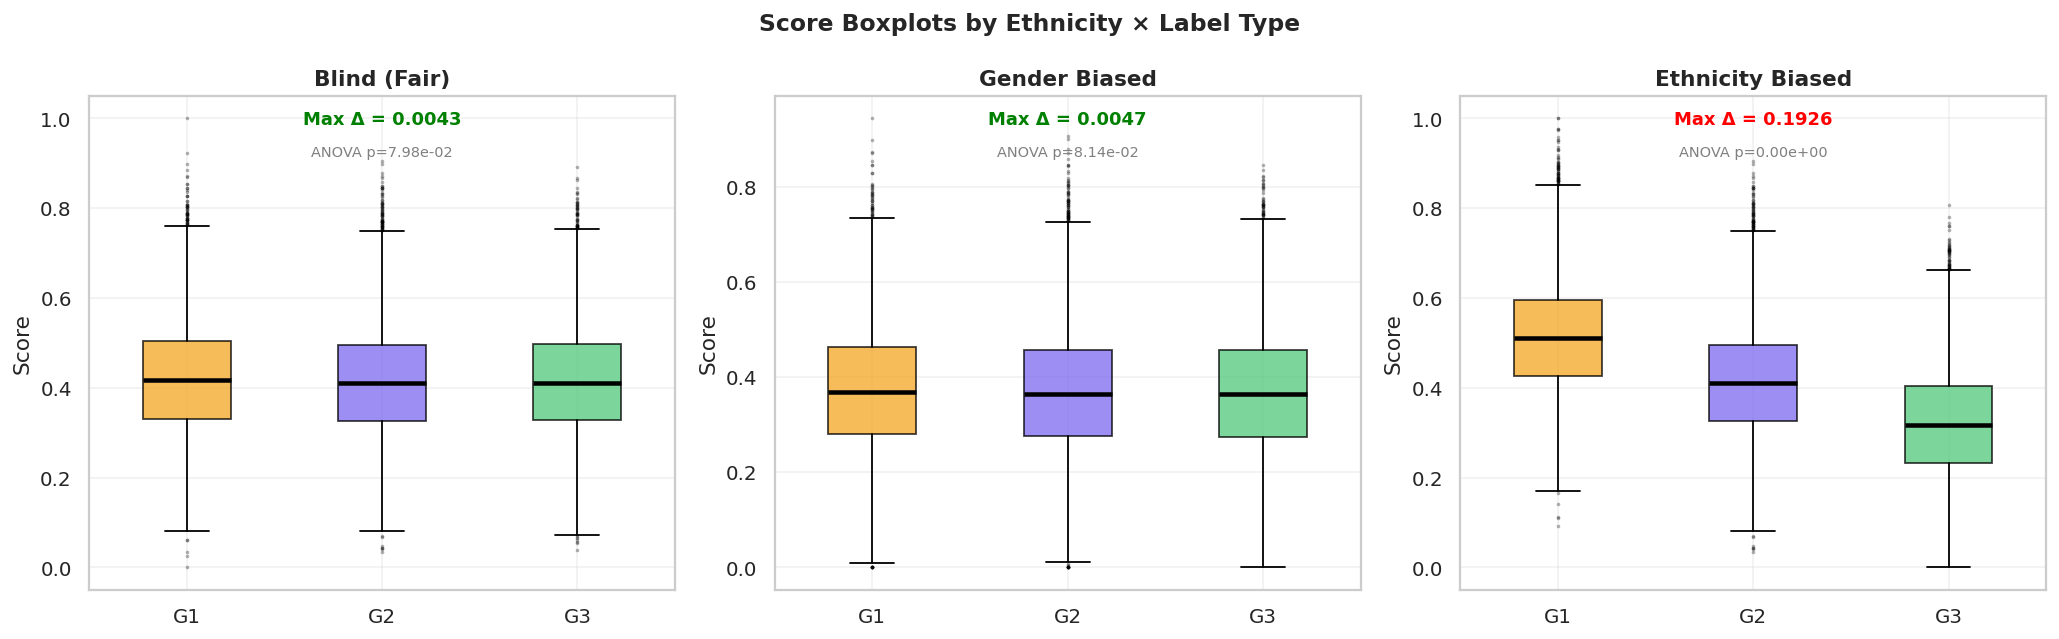

In [17]:
# ── 7d. Boxplots — Score by Ethnicity × Label ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Score Boxplots by Ethnicity × Label Type', fontsize=13, fontweight='bold')

for ax, col, name in zip(axes, LABEL_COLS, LABEL_NAMES):
    data = [df[df['ethnicity']==g][col].values for g in [0,1,2]]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.45,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, gid in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(PAL_ETH[gid]); patch.set_alpha(0.75)
    ax.set_xticklabels(['G1','G2','G3'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Score')
    means = [np.mean(d) for d in data]
    gap   = max(means) - min(means)
    ax.text(0.5, 0.97, f'Max Δ = {gap:.4f}',
            transform=ax.transAxes, ha='center', va='top',
            color='red' if gap > 0.005 else 'green',
            fontweight='bold', fontsize=10)
    f_stat, p = stats.f_oneway(*data)
    ax.text(0.5, 0.90, f'ANOVA p={p:.2e}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('sec7d_boxplot_ethnicity.png', bbox_inches='tight', dpi=150)
plt.show()

 Demographic Parity Gap Table:


,Label,Male μ,Female μ,Gender Gap,G1 μ,G2 μ,G3 μ,Ethnicity Gap
0,Blind (Fair),0.4174,0.4183,0.0009,0.4204,0.4172,0.4161,0.0043
1,Gender Biased,0.4174,0.3242,0.0933,0.3734,0.3702,0.3688,0.0047
2,Ethnicity Biased,0.4173,0.4183,0.0010,0.5145,0.4172,0.3219,0.1926


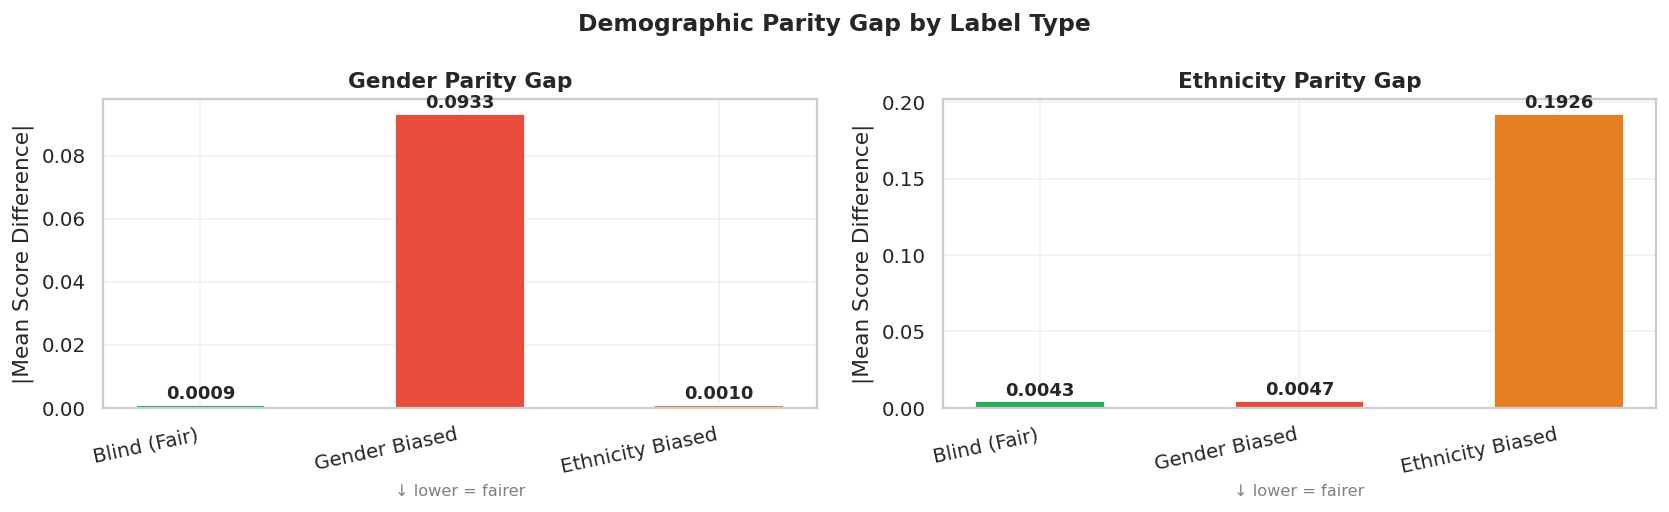

   Blind label shows near-zero demographic parity gap by design.
   Biased labels show significant gaps — exactly the bias injected.


In [18]:
# ── 7e. Demographic Parity Gap — quantified ─────────────────────────
dp_rows = []
for col, name in zip(LABEL_COLS, LABEL_NAMES):
    # Gender gap
    m_mean = df[df['gender']==0][col].mean()
    f_mean = df[df['gender']==1][col].mean()
    g_gap  = abs(m_mean - f_mean)
    # Ethnicity gap
    eth_means = [df[df['ethnicity']==g][col].mean() for g in [0,1,2]]
    e_gap     = max(eth_means) - min(eth_means)
    dp_rows.append({'Label': name,
                    'Male μ': round(m_mean,4), 'Female μ': round(f_mean,4),
                    'Gender Gap': round(g_gap,4),
                    'G1 μ': round(eth_means[0],4),
                    'G2 μ': round(eth_means[1],4),
                    'G3 μ': round(eth_means[2],4),
                    'Ethnicity Gap': round(e_gap,4)})

dp_df = pd.DataFrame(dp_rows)
print(' Demographic Parity Gap Table:')
display(dp_df)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Demographic Parity Gap by Label Type', fontsize=13, fontweight='bold')

for ax, col, title in zip(axes, ['Gender Gap','Ethnicity Gap'],
                                  ['Gender Parity Gap','Ethnicity Parity Gap']):
    vals = dp_df[col].values
    bars = ax.bar(dp_df['Label'], vals,
                  color=[PAL_LABEL['Blind'], PAL_LABEL['Gender Bias'], PAL_LABEL['Eth Bias']],
                  edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('|Mean Score Difference|')
    plt.setp(ax.get_xticklabels(), rotation=12, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
    ax.set_xlabel('↓ lower = fairer', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig('sec7e_dp_gap.png', bbox_inches='tight', dpi=150)
plt.show()
print('   Blind label shows near-zero demographic parity gap by design.')
print('   Biased labels show significant gaps — exactly the bias injected.')

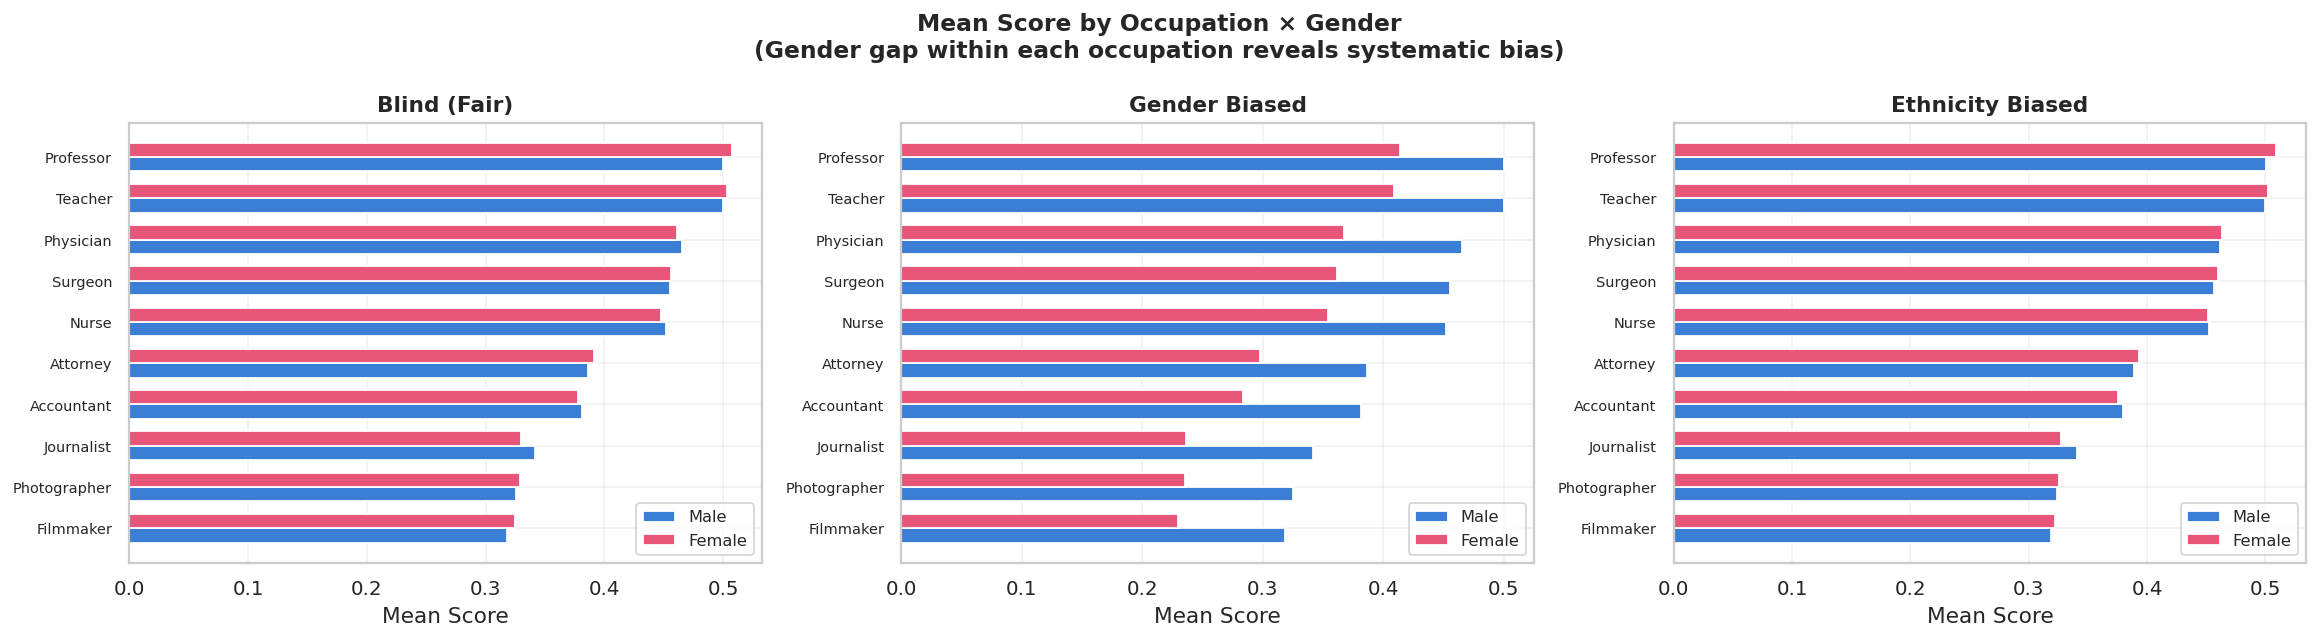

In [19]:
# ── 7f. Score by Occupation × Gender (interaction) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Mean Score by Occupation × Gender\n'
             '(Gender gap within each occupation reveals systematic bias)',
             fontsize=13, fontweight='bold')

for ax, col, name in zip(axes, LABEL_COLS, LABEL_NAMES):
    occ_gen = df.groupby(['occupation','gender_label'])[col].mean().unstack()
    occ_gen = occ_gen.sort_values('Male')
    x = np.arange(len(occ_gen))
    w = 0.35
    ax.barh(x - w/2, occ_gen['Male'],   w, color=PAL_GENDER[0],
            label='Male',   edgecolor='white')
    ax.barh(x + w/2, occ_gen['Female'], w, color=PAL_GENDER[1],
            label='Female', edgecolor='white')
    ax.set_yticks(x); ax.set_yticklabels(occ_gen.index, fontsize=8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Mean Score')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sec7f_occ_gender_score.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Correlation Analysis

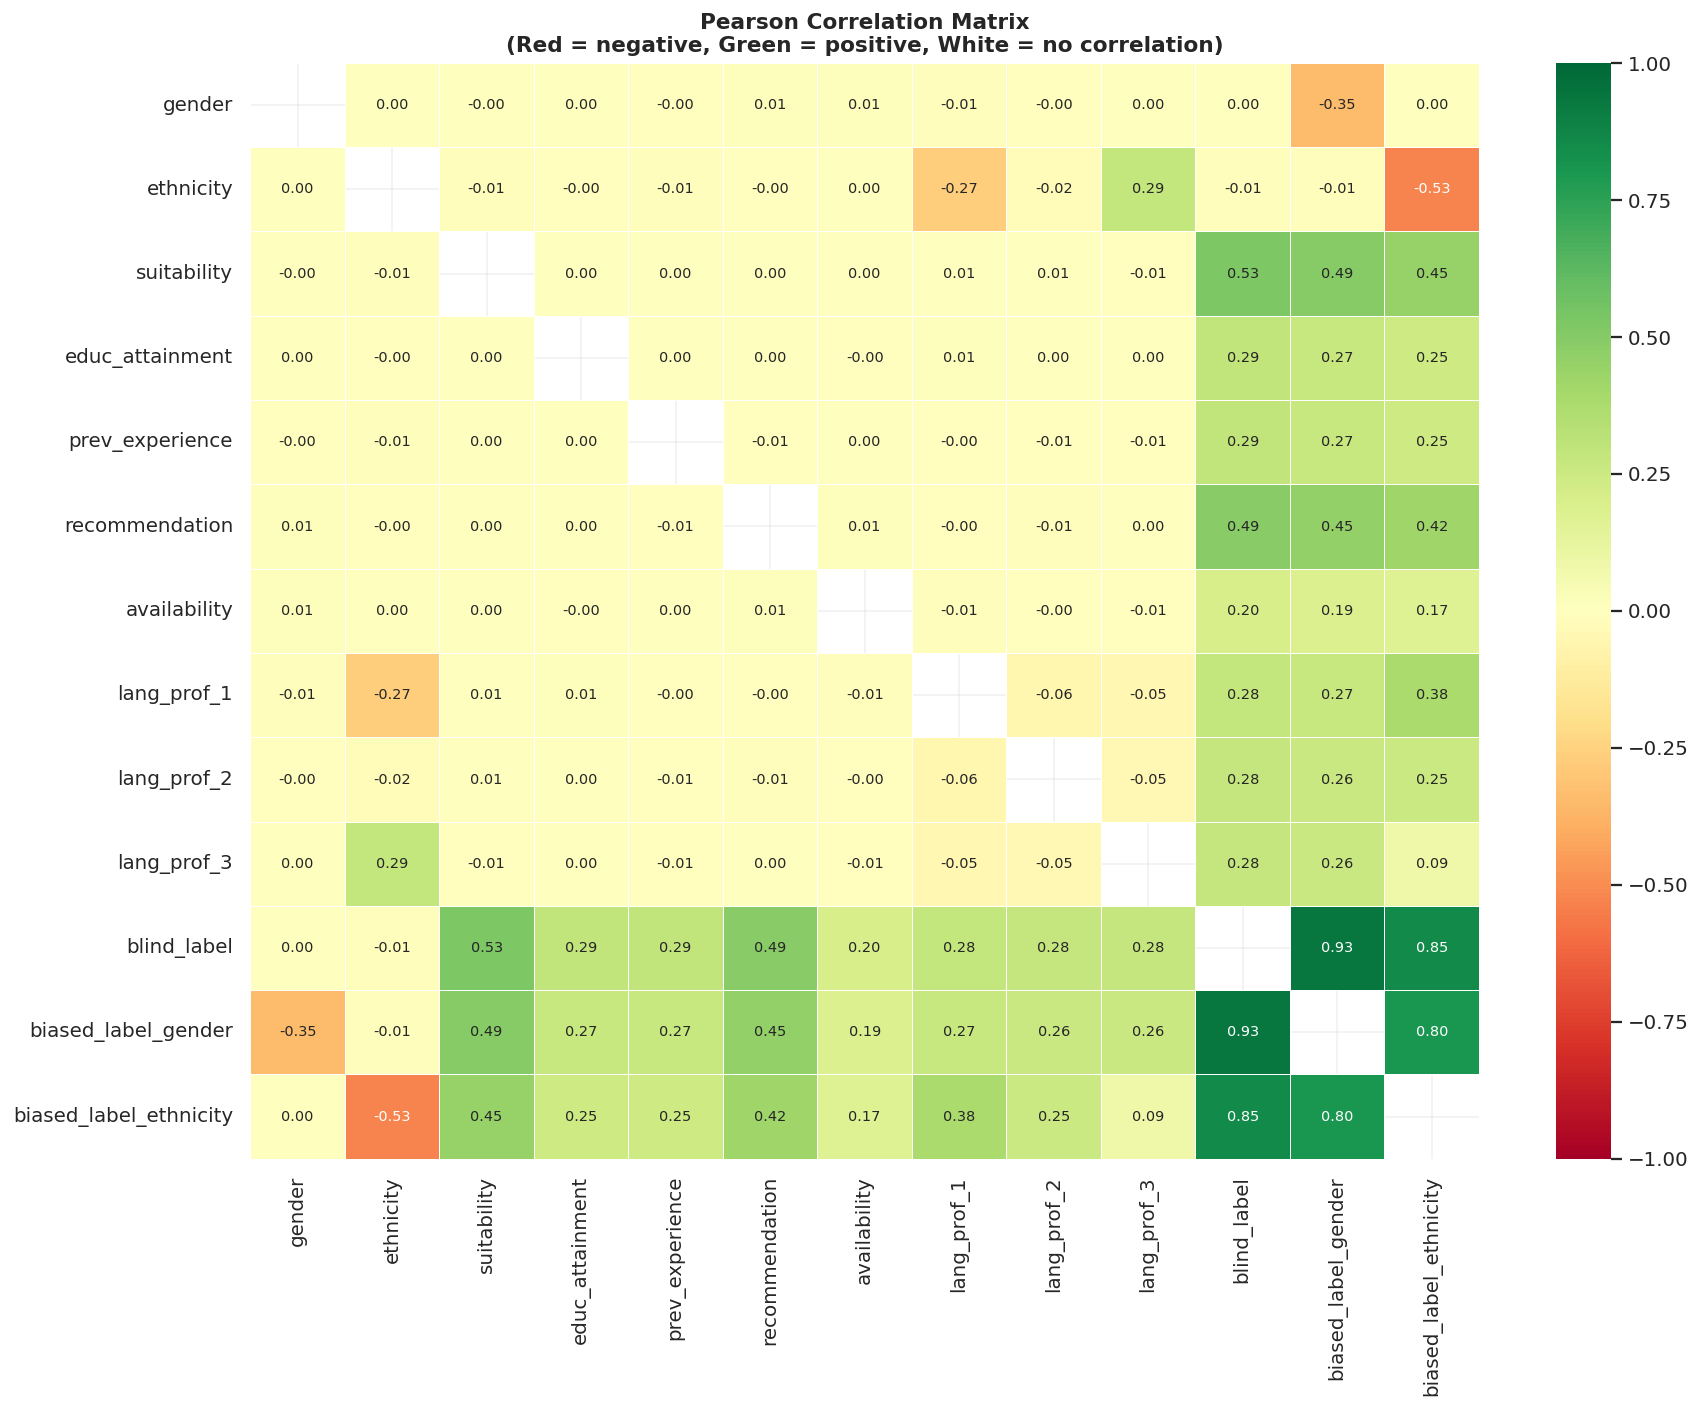

   Key: if gender/ethnicity show high correlation with biased labels,
   the model will learn to discriminate even without explicit demographic input.


In [20]:
# ════════════════════════════════════════════════════════════════════
# SECTION 8 — Correlation Analysis
#
# Why useful : Reveals which features drive the hiring score and
#              whether demographic attributes correlate with scores.
# Insight    : High correlation between demographic vars and biased
#              labels = model will learn discriminatory patterns.
# Fairness   : Demographic-score correlation is the root cause of
#              algorithmic discrimination.
# ════════════════════════════════════════════════════════════════════

# ── 8a. Full correlation heatmap ────────────────────────────────────
corr_cols = ['gender','ethnicity'] + COMPETENCY + LABEL_COLS
corr_mat  = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr_mat, dtype=bool)
np.fill_diagonal(mask, True)  # hide diagonal
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation Matrix\n'
             '(Red = negative, Green = positive, White = no correlation)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('sec8a_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('   Key: if gender/ethnicity show high correlation with biased labels,')
print('   the model will learn to discriminate even without explicit demographic input.')